# Proyecto Data Mining - CRISP-DM

**Integrantes:** Flavio Henriquez / Bastian Bianchi  
**Docente:** Italo Bonnet

## 1. Entendimiento del Negocio

Esta fase tiene por finalidad definir el problema de estudio, justificar su relevancia y delimitar el alcance del analisis. En coherencia con la metodologia CRISP-DM, el proposito inicial no es construir un modelo de manera inmediata, sino comprender con claridad que valor puede aportar el estudio de las precipitaciones diarias, que informacion se encuentra disponible, cuales son las principales restricciones del conjunto de datos y bajo que criterios se evaluara la pertinencia del trabajo desarrollado.


### 1.1 Contexto

Chile presenta una diversidad climatica y geografica muy marcada. En un mismo territorio coexisten sectores aridos, semiaridos, mediterraneos, templados lluviosos y frios patagonicos, por lo que la precipitacion no puede interpretarse de forma homogenea. Esta variabilidad convierte el estudio de las lluvias en un problema relevante para la gestion hidrica, la planificacion agricola, el monitoreo meteorologico, la prevencion de eventos extremos y la toma de decisiones territoriales.

El dataset utilizado contiene precipitaciones diarias registradas por estaciones meteorologicas chilenas. La granularidad diaria es pertinente porque permite observar no solo la magnitud de la lluvia, sino tambien su frecuencia, su estacionalidad y la persistencia de periodos secos. Ademas, la lectura del problema no se limita a la region administrativa: para esta entrega tambien resulta clave interpretar el fenomeno por estacion, zona geografica, macrozona y zona climatica.

Desde una perspectiva aplicada, el valor del analisis radica en transformar registros meteorologicos en informacion util para comprender donde, cuando y bajo que contexto territorial ocurre la precipitacion. Por ello, el entendimiento del negocio no se restringe a describir un archivo, sino a justificar por que la lluvia diaria debe leerse como un fenomeno simultaneamente temporal y territorial.


### 1.2 Datos relevantes

El analisis se sustenta en el archivo `dataset_precipitaciones_diarias_chile_COMPLETO.csv`, que contiene la serie diaria principal, y se complementa con `Set de datos/getEstacionesRedEma.json`, el cual permite asociar a los codigos tecnicos nombres descriptivos de estaciones, regiones y zonas geograficas. A partir de esa metadata, el estudio incorpora dos clasificaciones territoriales de apoyo: `macrozona` y `zona_climatica`. La `macrozona` se define como una agregacion territorial amplia, mientras que la `zona_climatica` se aproxima a partir de la ubicacion de cada estacion usando region, latitud, altitud y zona geografica, con el fin de representar de forma mas precisa regimenes de precipitacion comparables dentro de Chile.

**Resumen del conjunto**

| Aspecto | Valor observado | Relevancia para el proyecto |
| --- | --- | --- |
| Fuente principal | `dataset_precipitaciones_diarias_chile_COMPLETO.csv` | Contiene la base diaria usada para el analisis |
| Metadata complementaria | `Set de datos/getEstacionesRedEma.json` | Permite enriquecer los codigos con nombres de estacion, region y zona geografica |
| Granularidad base | 1 registro por estacion y por dia | Permite analizar frecuencia e intensidad diaria de precipitaciones |
| Periodo cubierto | 2021-01-01 a 2025-12-31 | Entrega continuidad temporal reciente de 5 anos |
| Cantidad de registros | 187,876 filas | Da volumen suficiente para detectar patrones temporales y territoriales |
| Estaciones meteorologicas | 109 | Aporta diversidad espacial y comparacion entre puntos de medicion |
| Regiones representadas | 16 | Entrega cobertura territorial amplia dentro de Chile |
| Zonas geograficas | 6 categorias | Resume relieve y emplazamiento de las estaciones |
| Macrozonas analiticas | 4 categorias | Permite una lectura sintetica Norte-Centro-Sur-Austral |
| Zonas climaticas analiticas | 13 categorias | Facilita una lectura territorial mas fina del regimen de precipitacion |
| Variable objetivo | `agua_caida` | Es la magnitud que se desea comprender y eventualmente predecir |
| Valores faltantes en `agua_caida` | 17,063 registros (9.08%) | Obliga a definir un tratamiento antes del modelamiento |

**Analisis.** La utilidad del conjunto no depende solo de su volumen, sino tambien de su capacidad para leerse en distintos niveles de agregacion. La estacion mantiene el detalle local, la zona geografica aporta contexto de relieve, la region permite una lectura administrativa, la macrozona resume grandes franjas territoriales y la zona climatica aproxima regimenes de precipitacion comparables. Esta granularidad multiescala resulta especialmente valiosa porque la lluvia diaria chilena no responde a un unico patron nacional, sino a combinaciones de territorio, estacionalidad y disponibilidad de datos.


### 1.3 Hipotesis y tesis consideradas

A partir del contexto del problema y de la estructura del dataset, se plantean las siguientes hipotesis de trabajo:

- La precipitacion diaria presenta un comportamiento estacional identificable, por lo que `mes`, `fecha` y posibles variables derivadas del calendario deberian explicar una parte relevante de la variacion observada en `agua_caida`.
- La ubicacion geografica de cada estacion, representada por `latitud`, `longitud`, `altura`, `region`, `zona_geografica` y `macrozona`, influye en la intensidad y en la frecuencia de las precipitaciones.
- La clasificacion por `zona_climatica` deberia distinguir mejor los regimenes de lluvia que la lectura exclusivamente administrativa por region, ya que agrupa territorios con comportamientos meteorologicos mas comparables.
- Existen diferencias estructurales entre estaciones meteorologicas; por lo tanto, `codigo_estacion` no solo actua como identificador, sino que tambien sintetiza condiciones locales de relieve, exposicion y microclima.
- La base diaria presenta una alta concentracion de dias sin precipitacion, por lo que la distribucion de la variable objetivo sera asimetrica y exigira especial cuidado interpretativo.
- Los valores faltantes de `agua_caida` deben revisarse antes de cualquier etapa posterior, ya que una concentracion no aleatoria por zona climatica, macrozona o periodo podria sesgar las conclusiones del analisis.
- Como proyeccion del proyecto, el caso puede formularse posteriormente como una tarea predictiva de regresion orientada a estimar la precipitacion diaria en milimetros.

**Analisis.** Estas hipotesis son consistentes con un enfoque CRISP-DM porque no parten desde un modelo, sino desde una comprension razonada del caso. La inclusion explicita de macrozonas y zonas climaticas ayuda a formular un problema mas realista: no se espera la misma dinamica de lluvia en un contexto arido del norte que en uno templado lluvioso o frio patagonico del sur austral.


### 1.4 KPI relevantes

En una entrega centrada en las primeras fases de CRISP-DM, los KPI mas pertinentes no corresponden todavia al rendimiento de un modelo final, sino a indicadores que permitan evaluar si el problema ha sido correctamente delimitado y si la base presenta condiciones adecuadas para continuar con el proceso analitico.

| KPI | Valor o criterio actual | Por que es relevante |
| --- | --- | --- |
| Cobertura temporal del dataset | 2021-01-01 a 2025-12-31 | Confirma que el analisis abarca 5 anos recientes y no solo una temporada aislada |
| Cobertura territorial fina | 109 estaciones en 16 regiones | Mide si el problema tiene representatividad geografica suficiente |
| Cobertura macrozonal | 4 macrozonas analiticas | Permite evaluar patrones amplios del territorio chileno |
| Cobertura climatica | 13 zonas climaticas analiticas | Permite contrastar regimenes de lluvia con mayor detalle |
| Completitud de `agua_caida` | 90.92% con dato disponible | Permite saber cuanta informacion util hay para analizar o modelar |
| Registros con `agua_caida = 0` | 67.68% del total | Advierte que la variable objetivo esta altamente concentrada en ausencia de lluvia |
| Registros con precipitacion positiva | 23.24% del total | Ayuda a dimensionar la frecuencia real de eventos de lluvia |
| Duplicados por estacion-fecha | 0 | Indica consistencia basica de la unidad de analisis diaria |

**Analisis.** Estos KPI muestran que la base es amplia y valiosa, pero no perfecta. La cobertura espacial es alta y permite una lectura multinivel, aunque la existencia de 9.08% de faltantes en la variable objetivo obliga a tratar la completitud como un KPI operativo central. En otras palabras, no basta con tener muchas estaciones; tambien es necesario asegurar que la informacion de precipitacion este disponible o tratada de manera defendible.


### 1.5 Problema de negocio (Analisis y proyeccion predictiva)

El problema de negocio consiste en comprender y dejar preparada una base analitica que permita explicar el comportamiento de la precipitacion diaria en estaciones meteorologicas chilenas. El valor esperado del proyecto radica en aportar informacion util para la gestion hidrica, el monitoreo de condiciones climaticas, la planificacion territorial y el analisis de riesgo asociado a periodos secos o a eventos de lluvia intensa.

La unidad de analisis del proyecto corresponde a cada combinacion `estacion-dia`. En dicho nivel, la variable objetivo es `agua_caida`, medida en milimetros, mientras que las variables disponibles describen ubicacion, contexto territorial y momento temporal del registro. Para interpretar mejor el problema, el analisis se organiza simultaneamente por estacion, zona geografica, region, macrozona y zona climatica. Esta lectura multiescala resulta especialmente importante porque el dataset contiene datos faltantes en `agua_caida`, de modo que comprender su distribucion territorial es parte del problema y no un detalle secundario.

**Analisis.** Dado que esta entrega prioriza el entendimiento del negocio y de los datos, el objetivo no consiste en prometer un modelo final, sino en formular correctamente el caso y preparar la base con criterio. En este sentido, una buena definicion del problema debe reconocer tanto la heterogeneidad territorial de la lluvia como la existencia de valores faltantes que podrian distorsionar el analisis si no se tratan con una estrategia coherente.


## 2. Entendimiento de los Datos

En esta fase se realiza una exploracion estructurada del dataset con el fin de identificar tipos de variables, valores faltantes, posibles outliers, distribuciones basicas, correlaciones y patrones relevantes. En coherencia con el material de apoyo, el objetivo no es solo describir los datos, sino tambien interpretar su calidad y anticipar decisiones de preparacion que permitan continuar el proceso de mineria de datos con mayor solidez.


### 2.1 Identificar Tipos de variables/atributos


En esta subseccion se distingue entre el tipo tecnico detectado por `pandas` y el tipo analitico que realmente cumple cada atributo dentro del problema. Esta distincion es importante porque varias columnas aparecen como numericas, pero conceptualmente funcionan como identificadores o categorias nominales y, por lo tanto, no deben interpretarse como magnitudes continuas.


In [1]:
# Si necesitas instalar dependencias en este notebook:
# !pip install "pandas" "numpy" "matplotlib" "scikit-learn"

from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)

base_path = Path("dataset_precipitaciones_diarias_chile_COMPLETO.csv")
meta_path = Path("Set de datos") / "getEstacionesRedEma.json"


En esta primera celda solo se preparan las dependencias, la configuracion visual y las rutas de trabajo. Si el entorno no dispone de alguna libreria necesaria, la instalacion puede realizarse aparte, pero no se deja embebida dentro del codigo para mantener el flujo del notebook mas limpio.


In [2]:
def heatmap_df(data, title, cmap="Blues", figsize=(8, 5), decimals=2, xlabel="Eje X", ylabel="Eje Y", cbar_label="Valor", na_text=""):
    fig, ax = plt.subplots(figsize=figsize)
    matrix = data.astype(float).values
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#f8fafc")
    masked = np.ma.masked_invalid(matrix)
    im = ax.imshow(masked, cmap=cmap_obj, aspect="auto")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    for row in range(data.shape[0]):
        for col in range(data.shape[1]):
            value = matrix[row, col]
            if np.isnan(value):
                if na_text:
                    ax.text(col, row, na_text, ha="center", va="center", fontsize=7, color="#64748b")
            else:
                ax.text(col, row, f"{value:.{decimals}f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()


def plot_group_heatmaps(corr_dict, title_prefix, cmap="coolwarm", decimals=2, ncols=2, base_figsize=(5.5, 4.2), xlabel="Variables", ylabel="Variables", cbar_label="Correlacion"):
    items = [(grupo, matriz) for grupo, matriz in corr_dict.items() if matriz is not None and not matriz.empty]
    if not items:
        print("No hay matrices para graficar.")
        return

    ncols = min(ncols, len(items))
    nrows = int(np.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(base_figsize[0] * ncols, base_figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()
    image = None
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#f8fafc")

    for ax, (grupo, matriz) in zip(axes, items):
        matrix = matriz.astype(float).values
        masked = np.ma.masked_invalid(matrix)
        image = ax.imshow(masked, cmap=cmap_obj, aspect="auto", vmin=-1, vmax=1)
        ax.set_xticks(range(len(matriz.columns)))
        ax.set_xticklabels(matriz.columns, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(matriz.index)))
        ax.set_yticklabels(matriz.index, fontsize=8)
        for row in range(matriz.shape[0]):
            for col in range(matriz.shape[1]):
                value = matrix[row, col]
                if not np.isnan(value):
                    ax.text(col, row, f"{value:.{decimals}f}", ha="center", va="center", fontsize=7)
        ax.set_title(f"{title_prefix}: {grupo}", fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    for ax in axes[len(items):]:
        ax.axis("off")

    fig.subplots_adjust(right=0.88, wspace=0.45, hspace=0.6)
    if image is not None:
        cax = fig.add_axes([0.9, 0.2, 0.015, 0.6])
        cbar = fig.colorbar(image, cax=cax)
        cbar.set_label(cbar_label)

    plt.show()


def build_group_corr_dict(data, group_col, numeric_cols, group_order=None, min_rows=30, drop_constant=False):
    groups = group_order if group_order is not None else list(pd.Series(data[group_col]).dropna().unique())
    corr_dict = {}

    for group in groups:
        subset = data.loc[data[group_col] == group, numeric_cols].dropna()
        if drop_constant:
            subset = subset.loc[:, subset.nunique(dropna=True) > 1]
        if len(subset) >= min_rows and subset.shape[1] >= 2:
            corr_dict[group] = subset.corr(numeric_only=True).round(3)

    return corr_dict


Las funciones de visualizacion quedan separadas porque se reutilizan varias veces en el notebook. `heatmap_df` se usa para una sola matriz, mientras que `plot_group_heatmaps` permite repetir la misma lectura por segmentos territoriales, en este caso por `zona_geografica`, sin convertir cada subseccion en un bloque manual demasiado extenso.


In [3]:
MACROZONE_ORDER = ["Norte", "Centro", "Sur", "Austral", "Otra"]
MACROZONE_MARKERS = {
    "Norte": "o",
    "Centro": "s",
    "Sur": "^",
    "Austral": "D",
    "Otra": "X",
}
MACROZONE_OFFSETS = {
    "Norte": -0.24,
    "Centro": -0.08,
    "Sur": 0.08,
    "Austral": 0.24,
    "Otra": 0.0,
}

MACROZONE_COLORS = {
    "Norte": "#0f766e",
    "Centro": "#2563eb",
    "Sur": "#7c3aed",
    "Austral": "#ea580c",
    "Otra": "#64748b",
}

def region_to_macrozone(region_code):
    if region_code in [15, 1, 2, 3, 4]:
        return "Norte"
    if region_code in [5, 13, 6, 7]:
        return "Centro"
    if region_code in [16, 8, 9, 14, 10]:
        return "Sur"
    if region_code in [11, 12]:
        return "Austral"
    return "Otra"


def infer_climate_zone(region_code, latitud, altura, zona_geografica):
    if pd.isna(region_code) or pd.isna(latitud):
        return "Otra"

    region_code = int(region_code)
    lat_sur = abs(float(latitud))
    altura = 0 if pd.isna(altura) else float(altura)
    zona = "" if pd.isna(zona_geografica) else str(zona_geografica)

    if region_code in [15, 1, 2]:
        if lat_sur <= 19.5 and altura >= 3200:
            return "Tropical lluvioso"
        if altura >= 2500 or zona in ["Cordillera", "PreCordillera"]:
            return "Des?rtico y Estep?rico de altura"
        if zona == "Litoral":
            return "Des?rtico costero"
        return "Des?rtico normal"

    if region_code in [3, 4]:
        if altura >= 2200 or zona in ["Cordillera", "PreCordillera"]:
            return "Des?rtico y Estep?rico de altura"
        if zona in ["Litoral", "Secano Costero"]:
            return "Estep?rico costero"
        return "Estep?rico interior"

    if region_code in [5, 13, 6, 7]:
        return "Mediterr?neo seco"

    if region_code in [16, 8]:
        return "Mediterr?neo seco y h?medo"

    if region_code in [9, 14, 10]:
        if zona == "Litoral":
            return "Mar?timo lluvioso"
        return "Templado y lluvioso"

    if region_code == 11:
        if zona == "Litoral":
            return "Mar?timo lluvioso"
        return "Estepario fr?o"

    if region_code == 12:
        if lat_sur >= 53:
            return "Tundra"
        if altura >= 1200 or zona in ["Cordillera", "PreCordillera"]:
            return "Hielo de alturas y clima polar"
        if zona == "Litoral":
            return "Mar?timo lluvioso"
        return "Estepario fr?o"

    return "Otra"


CLIMATE_ORDER = [
    "Tropical lluvioso",
    "Des?rtico costero",
    "Des?rtico normal",
    "Des?rtico y Estep?rico de altura",
    "Estep?rico costero",
    "Estep?rico interior",
    "Mediterr?neo seco",
    "Mediterr?neo seco y h?medo",
    "Templado y lluvioso",
    "Mar?timo lluvioso",
    "Estepario fr?o",
    "Tundra",
    "Hielo de alturas y clima polar",
]
CLIMATE_COLORS = {
    "Tropical lluvioso": "#16a34a",
    "Des?rtico costero": "#f59e0b",
    "Des?rtico normal": "#d97706",
    "Des?rtico y Estep?rico de altura": "#c2410c",
    "Estep?rico costero": "#fb923c",
    "Estep?rico interior": "#f97316",
    "Mediterr?neo seco": "#84cc16",
    "Mediterr?neo seco y h?medo": "#65a30d",
    "Templado y lluvioso": "#2563eb",
    "Mar?timo lluvioso": "#0ea5e9",
    "Estepario fr?o": "#8b5cf6",
    "Tundra": "#64748b",
    "Hielo de alturas y clima polar": "#e2e8f0",
}


def add_class_legends(ax, climate_values=None, macro_values=None):
    climate_values = ACTIVE_CLIMATE_ORDER if climate_values is None else list(climate_values)
    macro_values = MACROZONE_ORDER if macro_values is None else list(macro_values)

    climate_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=CLIMATE_COLORS.get(zona, "#94a3b8"),
            markeredgecolor="#0f172a",
            markersize=8,
            label=zona,
        )
        for zona in climate_values
    ]
    macro_handles = [
        Line2D(
            [0],
            [0],
            marker=MACROZONE_MARKERS.get(macrozona, "o"),
            linestyle="",
            color="#0f172a",
            markersize=8,
            label=macrozona,
        )
        for macrozona in macro_values
    ]

    legend_clima = ax.legend(
        handles=climate_handles,
        title="Zona climatica",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    ax.add_artist(legend_clima)
    ax.legend(
        handles=macro_handles,
        title="Macrozona",
        bbox_to_anchor=(1.02, 0.35),
        loc="upper left",
    )


Primero se dejan preparadas las librerias, funciones auxiliares y rutas de trabajo. Esta separacion ayuda a que la carga y el enriquecimiento del dataset se entiendan como pasos distintos y no como una sola celda extensa.


In [4]:
df_csv = pd.read_csv(base_path)

print(f"Shape base CSV: {df_csv.shape}")
display(df_csv.head())


Shape base CSV: (187876, 10)


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha
0,170001,15,4084,-17.595,-69.4775,2023,1,1,NaN,2023-01-01
1,170001,15,4084,-17.595,-69.4775,2023,1,2,NaN,2023-01-02
2,170001,15,4084,-17.595,-69.4775,2023,1,3,NaN,2023-01-03
3,170001,15,4084,-17.595,-69.4775,2023,1,4,NaN,2023-01-04
4,170001,15,4084,-17.595,-69.4775,2023,1,5,NaN,2023-01-05


La lectura inicial del CSV permite verificar el tamaño de la serie diaria antes de mezclarla con metadata externa. Este paso deja claro cual es la fuente principal del analisis.


In [5]:
meta_json = json.loads(meta_path.read_text(encoding="utf-8"))
meta_df = (
    pd.DataFrame(meta_json["datosEstacion"])[
        ["codigoNacional", "region", "nombreEstacion", "NombreRegion", "zonaGeografica"]
    ]
    .rename(
        columns={
            "codigoNacional": "codigo_estacion",
            "nombreEstacion": "nombre_estacion",
            "NombreRegion": "nombre_region",
            "zonaGeografica": "zona_geografica",
        }
    )
    .drop_duplicates(subset=["codigo_estacion", "region"])
)

print(f"Shape metadata estaciones: {meta_df.shape}")
display(meta_df.head())


Shape metadata estaciones: (148, 5)


,codigo_estacion,region,nombre_estacion,nombre_region,zona_geografica
0,170001,15,Visviri Tenencia,Arica y Parinacota,Cordillera
1,180005,15,"Chacalluta, Arica Ap.",Arica y Parinacota,Litoral
2,180017,15,Putre,Arica y Parinacota,PreCordillera
3,180018,15,"Defensa Civil, Arica",Arica y Parinacota,Litoral
4,180042,15,"Cerro Sombrero, Arica",Arica y Parinacota,Litoral


En este punto todavia existen dos fuentes separadas: la serie diaria y la metadata descriptiva. La segunda es clave porque transforma codigos tecnicos en nombres de estacion, region y zona geografica, lo que vuelve mucho mas interpretable el analisis posterior.


In [6]:
df = (
    df_csv.merge(meta_df, on=["codigo_estacion", "region"], how="left")
          .sort_values(["codigo_estacion", "fecha"])
          .reset_index(drop=True)
)
df["fecha"] = pd.to_datetime(df["fecha"])
df["macrozona"] = df["region"].apply(region_to_macrozone)
df["zona_climatica"] = df.apply(
    lambda row: infer_climate_zone(
        row["region"],
        row["latitud"],
        row["altura"],
        row["zona_geografica"],
    ),
    axis=1,
)
ACTIVE_CLIMATE_ORDER = [zona for zona in CLIMATE_ORDER if zona in df["zona_climatica"].dropna().unique()]
ACTIVE_GEO_ORDER = sorted(df["zona_geografica"].dropna().unique())
print("Zonas climaticas activas:", ", ".join(ACTIVE_CLIMATE_ORDER))
print("Zonas geograficas activas:", ", ".join(ACTIVE_GEO_ORDER))

print(f"Dimension del dataset enriquecido: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Periodo disponible: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Estaciones con metadata: {df['nombre_estacion'].nunique()}")
print(f"Regiones representadas: {df['nombre_region'].nunique()}")
print(f"Macrozonas analiticas: {df['macrozona'].nunique()}")
print(f"Zonas climaticas analiticas activas: {df['zona_climatica'].nunique()}")
print(f"Zonas geograficas analiticas activas: {df['zona_geografica'].nunique()}")
display(df.head())


Zonas climaticas activas: Tropical lluvioso, Des?rtico costero, Des?rtico y Estep?rico de altura, Estep?rico costero, Estep?rico interior, Mediterr?neo seco, Mediterr?neo seco y h?medo, Templado y lluvioso, Mar?timo lluvioso, Estepario fr?o, Tundra
Zonas geograficas activas: Cordillera, Litoral, PreCordillera, Secano Costero, Secano Interior, Valle
Dimension del dataset enriquecido: 187876 filas x 15 columnas
Periodo disponible: 2021-01-01 a 2025-12-31
Estaciones con metadata: 109
Regiones representadas: 16
Macrozonas analiticas: 4
Zonas climaticas analiticas activas: 11
Zonas geograficas analiticas activas: 6


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha,nombre_estacion,nombre_region,zona_geografica,macrozona,zona_climatica
0,170001,15,4084,-17.595,-69.4775,2023,1,1,NaN,2023-01-01,Visviri Tenencia,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso
1,170001,15,4084,-17.595,-69.4775,2023,1,2,NaN,2023-01-02,Visviri Tenencia,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso
2,170001,15,4084,-17.595,-69.4775,2023,1,3,NaN,2023-01-03,Visviri Tenencia,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso
3,170001,15,4084,-17.595,-69.4775,2023,1,4,NaN,2023-01-04,Visviri Tenencia,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso
4,170001,15,4084,-17.595,-69.4775,2023,1,5,NaN,2023-01-05,Visviri Tenencia,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso


Una vez realizado el merge, la base ya puede analizarse como un conjunto enriquecido. Desde aqui en adelante no solo tenemos precipitacion y coordenadas, sino tambien contexto territorial legible para interpretar patrones por estacion y por region.


In [7]:
resumen_base = pd.DataFrame(
    {
        "dtype_pandas": df.dtypes.astype(str),
        "valores_unicos": df.nunique(dropna=False),
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "valores_unicos"], ascending=[False, False])

display(resumen_base)


,dtype_pandas,valores_unicos,nulos,porcentaje_nulos
agua_caida,float64,739,17063,9.08
fecha,datetime64[ns],1826,0,0.00
codigo_estacion,int64,109,0,0.00
latitud,float64,109,0,0.00
longitud,float64,109,0,0.00
nombre_estacion,object,109,0,0.00
altura,int64,99,0,0.00
dia,int64,31,0,0.00
region,int64,16,0,0.00
nombre_region,object,16,0,0.00


Este resumen tecnico permite mirar rapidamente la estructura real de cada columna: tipo detectado, cardinalidad y presencia de nulos. Es un paso util antes de decidir que variables deben tratarse como identificadores, cuales como predictores y cuales requieren limpieza.


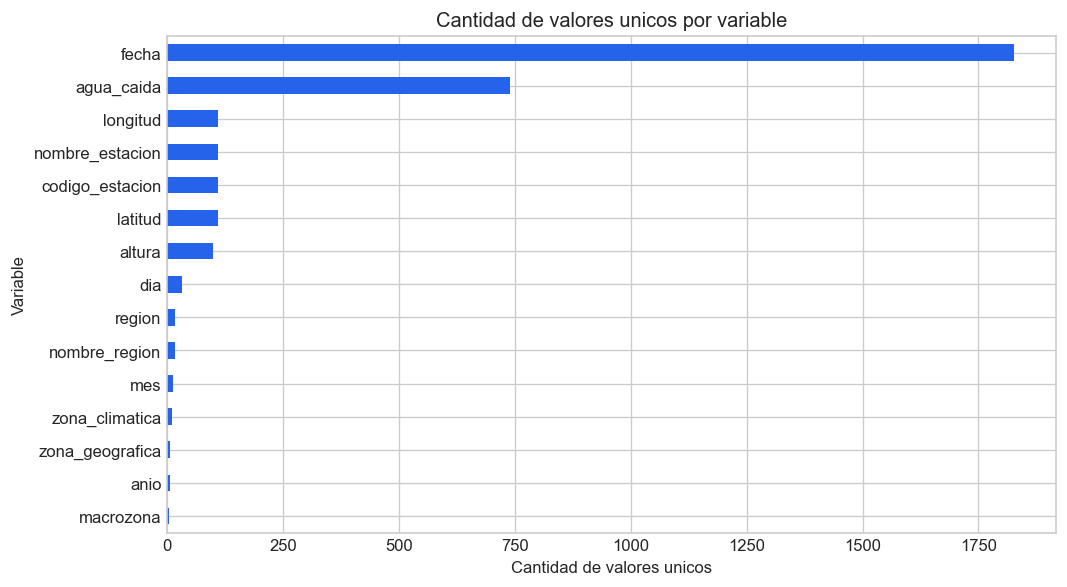

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
resumen_base["valores_unicos"].sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Cantidad de valores unicos por variable")
ax.set_xlabel("Cantidad de valores unicos")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


In [9]:
clasificacion_variables = pd.DataFrame(
    {
        "variable": [
            "codigo_estacion", "nombre_estacion", "region", "nombre_region", "zona_geografica",
            "altura", "latitud", "longitud", "anio", "mes", "dia", "fecha", "agua_caida"
        ],
        "tipo_analitico": [
            "Categorica nominal codificada", "Categorica nominal", "Categorica nominal codificada",
            "Categorica nominal", "Categorica nominal", "Numerica discreta", "Numerica continua",
            "Numerica continua", "Numerica discreta temporal", "Numerica discreta temporal",
            "Numerica discreta temporal", "Temporal", "Numerica continua"
        ],
        "rol_en_el_proyecto": [
            "Identificador tecnico de estacion", "Identificador descriptivo de estacion",
            "Codigo territorial", "Referencia territorial descriptiva", "Contexto geografico agregado",
            "Predictor geografico", "Predictor geografico", "Predictor geografico",
            "Predictor temporal", "Predictor temporal", "Predictor temporal",
            "Secuencia cronologica", "Variable objetivo"
        ],
    }
)

display(clasificacion_variables)


,variable,tipo_analitico,rol_en_el_proyecto
0,codigo_estacion,Categorica nominal codificada,Identificador tecnico de estacion
1,nombre_estacion,Categorica nominal,Identificador descriptivo de estacion
2,region,Categorica nominal codificada,Codigo territorial
3,nombre_region,Categorica nominal,Referencia territorial descriptiva
4,zona_geografica,Categorica nominal,Contexto geografico agregado
5,altura,Numerica discreta,Predictor geografico
6,latitud,Numerica continua,Predictor geografico
7,longitud,Numerica continua,Predictor geografico
8,anio,Numerica discreta temporal,Predictor temporal
9,mes,Numerica discreta temporal,Predictor temporal


**Analisis.** El dataset enriquecido queda compuesto por 15 variables: tres categoricas textuales, dos codigos numericos de naturaleza nominal, seis variables numericas de apoyo analitico, una variable temporal completa (`fecha`), la variable objetivo `agua_caida` y dos clasificaciones territoriales derivadas (`macrozona` y `zona_climatica`). Un punto metodologico importante es que `codigo_estacion` y `region` no deben interpretarse como magnitudes continuas, ya que sus valores expresan etiquetas y no distancias reales entre categorias. La incorporacion adicional de `macrozona` y `zona_climatica` refuerza la lectura territorial del problema y prepara mejor las fases exploratorias posteriores.


### 2.2 Identificar Nulos


Tal como se enfatiza en el material de apoyo, la revision de valores faltantes debe realizarse antes de cualquier transformacion relevante. En esta etapa no solo interesa cuantificar si existen nulos, sino tambien identificar en que variable se concentran y si su distribucion cambia segun zona climatica, macrozona, zona geografica o anio.


In [10]:
tabla_nulos = pd.DataFrame(
    {
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "porcentaje_nulos"], ascending=False)

display(tabla_nulos)


,nulos,porcentaje_nulos
agua_caida,17063,9.08
codigo_estacion,0,0.00
region,0,0.00
altura,0,0.00
latitud,0,0.00
longitud,0,0.00
anio,0,0.00
mes,0,0.00
dia,0,0.00
fecha,0,0.00


Una vez identificado el panorama general de nulos, conviene bajar el analisis a segmentos concretos. En este caso interesa revisar si la ausencia de `agua_caida` cambia segun zona climatica, macrozona, zona geografica y anio, ya que esa distribucion puede afectar la lectura territorial posterior.


In [11]:
nulos_zona_climatica = (
    df.groupby("zona_climatica")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .reindex(ACTIVE_CLIMATE_ORDER)
)

nulos_macrozona = (
    df.groupby("macrozona")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .reindex(MACROZONE_ORDER)
)

nulos_zona_geografica = (
    df.groupby("zona_geografica")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .sort_values("porcentaje_nulos", ascending=False)
)

nulos_anio = (
    df.groupby("anio")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .reset_index()
      .sort_values("anio")
)

display(nulos_zona_climatica)
display(nulos_macrozona)
display(nulos_zona_geografica)
display(nulos_anio.head())


,total,nulos,porcentaje_nulos
zona_climatica,,,
Tropical lluvioso,4018,586,14.58
Des?rtico costero,14604,1095,7.50
Des?rtico y Estep?rico de altura,6795,1205,17.73
Estep?rico costero,5451,161,2.95
Estep?rico interior,12673,1146,9.04
Mediterr?neo seco,67445,4428,6.57
Mediterr?neo seco y h?medo,13147,1040,7.91
Templado y lluvioso,21177,2778,13.12
Mar?timo lluvioso,17741,3023,17.04


,total,nulos,porcentaje_nulos
macrozona,,,
Norte,43541.0,4193.0,9.63
Centro,67445.0,4428.0,6.57
Sur,47106.0,6047.0,12.84
Austral,29784.0,2395.0,8.04
Otra,NaN,NaN,NaN


,total,nulos,porcentaje_nulos
zona_geografica,,,
PreCordillera,19060,3162,16.59
Cordillera,7527,1203,15.98
Secano Interior,2557,272,10.64
Litoral,64838,5451,8.41
Valle,86617,6757,7.80
Secano Costero,7277,218,3.00


,total,nulos,porcentaje_nulos
anio,,,
2021,35606,4215,11.84
2022,35735,3412,9.55
2023,38325,4799,12.52
2024,39162,2954,7.54
2025,39048,1683,4.31


Las tablas anteriores dejan cuantificado el problema de completitud por segmento. El grafico siguiente resume esa misma idea a nivel de variable y permite ver de inmediato que el foco real de los faltantes esta concentrado en `agua_caida`, no repartido por toda la base.


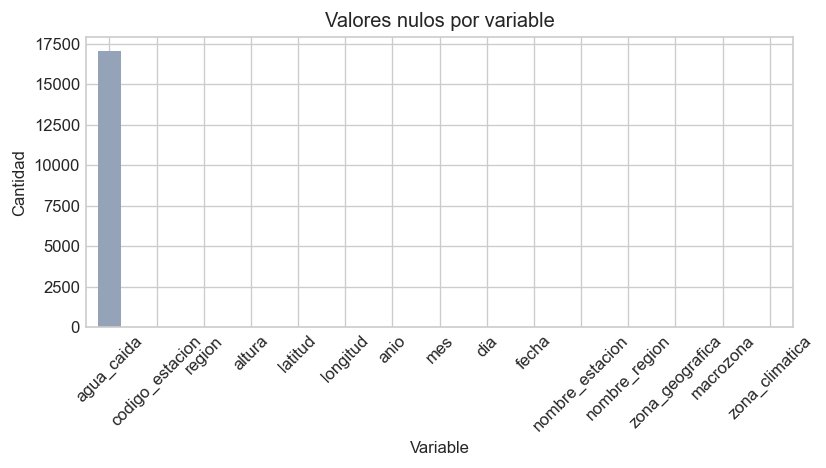

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
tabla_nulos["nulos"].plot(kind="bar", ax=ax, color="#94a3b8")
ax.set_title("Valores nulos por variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [100]:
nulos_macrozona = nulos_macrozona.query("macrozona != 'Otra'")

Despues del panorama general, conviene visualizar la concentracion de nulos en agregaciones territoriales mas interpretables. La zona climatica permite comparar regimenes de lluvia similares y la macrozona resume grandes franjas del pais. En el caso del anio, el resumen se deja con `anio` como columna explicita para que el `head()` sea mas legible, y la figura se presenta como grafico de torta usando la participacion de los nulos totales por anio, ya que ese formato representa mejor partes de un mismo total.


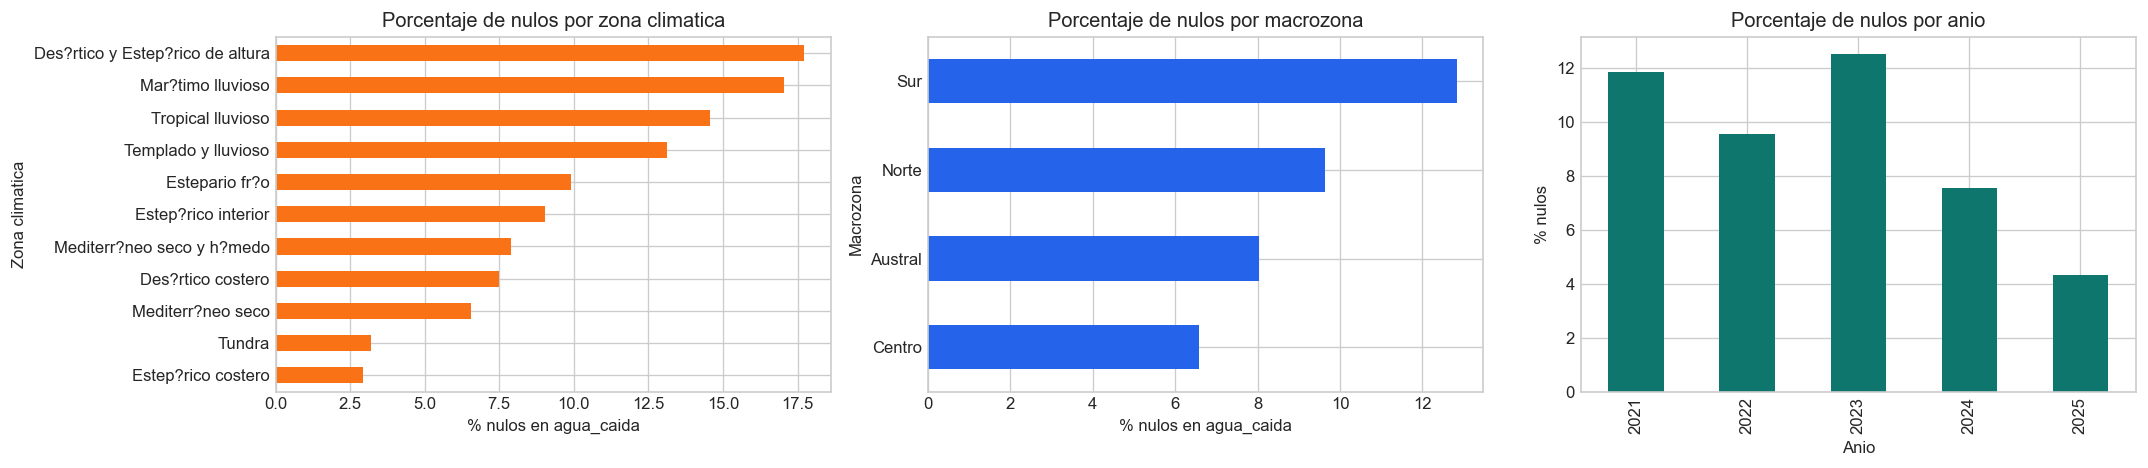

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

nulos_zona_climatica["porcentaje_nulos"].sort_values().plot(kind="barh", ax=axes[0], color="#f97316")
axes[0].set_title("Porcentaje de nulos por zona climatica")
axes[0].set_xlabel("% nulos en agua_caida")
axes[0].set_ylabel("Zona climatica")

nulos_macrozona["porcentaje_nulos"].sort_values().plot(kind="barh", ax=axes[1], color="#2563eb")
axes[1].set_title("Porcentaje de nulos por macrozona")
axes[1].set_xlabel("% nulos en agua_caida")
axes[1].set_ylabel("Macrozona")

participacion_nulos_anio = nulos_anio.loc[nulos_anio["nulos"] > 0, ["anio", "nulos"]]
axes[2].pie(
    participacion_nulos_anio["nulos"],
    labels=participacion_nulos_anio["anio"].astype(str),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
axes[2].set_title("Participacion de nulos totales por anio")
axes[2].axis("equal")

plt.tight_layout()
plt.show()


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha,nombre_estacion,nombre_region,zona_geografica,macrozona,zona_climatica


**Analisis.** El diagnostico muestra que los valores faltantes se concentran exclusivamente en `agua_caida`, con 17,063 registros nulos equivalentes al 9.08% del total. Sin embargo, la ausencia no se distribuye de forma completamente uniforme: ciertas zonas climaticas y macrozonas concentran porcentajes mayores, lo que sugiere que el problema de completitud tiene un componente territorial ademas del temporal. En la tabla anual, `anio` queda como columna explicita para hacer mas clara la lectura del resumen; en la torta, cada segmento representa la fraccion del total de nulos acumulados que aporta ese anio. Esto refuerza la necesidad de un tratamiento de nulos que respete similitud espacial y estacional, en vez de aplicar un reemplazo global indiferenciado.


### 2.3 Identificar Outliers


La deteccion de outliers debe realizarse con criterio estadistico y tambien con criterio de dominio. En precipitaciones diarias es esperable encontrar una distribucion muy asimetrica, con gran cantidad de ceros y pocos eventos intensos. Por ello se utiliza el rango intercuartil (IQR) como primera referencia robusta: al basarse en Q1 y Q3, resiste mejor los extremos que la media y la desviacion estandar y no exige asumir una distribucion normal. Aun asi, en una variable zero-inflated como `agua_caida`, el IQR no debe interpretarse como una regla automatica de eliminacion, sino como un umbral inicial para diagnosticar que tan alejados estan los eventos intensos del comportamiento habitual.


In [14]:
distribucion_lluvia = pd.DataFrame(
    {
        "indicador": ["Dias sin precipitacion", "Dias con precipitacion", "Registros nulos"],
        "porcentaje": [
            round((df["agua_caida"] == 0).mean() * 100, 2),
            round((df["agua_caida"] > 0).mean() * 100, 2),
            round(df["agua_caida"].isna().mean() * 100, 2),
        ],
    }
)

display(distribucion_lluvia)


,indicador,porcentaje
0,Dias sin precipitacion,67.68
1,Dias con precipitacion,23.24
2,Registros nulos,9.08


El primer paso muestra la composicion general de la variable objetivo. Si predominan los ceros, cualquier regla automatica basada solo en dispersion tendera a sobredetectar supuestos outliers, por lo que conviene interpretar con especial cautela los resultados siguientes.


In [15]:
q1 = df["agua_caida"].quantile(0.25)
q3 = df["agua_caida"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
p95 = df["agua_caida"].quantile(0.95)
p99 = df["agua_caida"].quantile(0.99)


Con el criterio IQR y los percentiles altos ya calculados, se resume la magnitud real del problema. Separar el calculo del reporte final ayuda a distinguir entre el umbral estadistico y su interpretacion analitica posterior.


In [16]:
resumen_outliers = pd.DataFrame(
    {
        "Q1": [round(q1, 2)],
        "Q3": [round(q3, 2)],
        "IQR": [round(iqr, 2)],
        "Limite_superior_IQR": [round(upper, 2)],
        "Percentil_95": [round(p95, 2)],
        "Percentil_99": [round(p99, 2)],
        "Registros_sobre_IQR": [int((df["agua_caida"] > upper).sum())],
        "Registros_sobre_P99": [int((df["agua_caida"] >= p99).sum())],
        "Registros_mayores_100mm": [int((df["agua_caida"] > 100).sum())],
        "Registros_mayores_500mm": [int((df["agua_caida"] > 500).sum())],
    }
)

display(resumen_outliers)


,Q1,Q3,IQR,Limite_superior_IQR,Percentil_95,Percentil_99,Registros_sobre_IQR,Registros_sobre_P99,Registros_mayores_100mm,Registros_mayores_500mm
0,0.0,0.1,0.1,0.25,8.6,27.8,32994,1726,21,5


Aqui ya se observa si el limite IQR resulta demasiado sensible para una variable con muchos ceros. Compararlo con percentiles altos permite separar mejor lo que es simplemente lluvia positiva de lo que realmente parece un valor extremo dentro del conjunto.


In [17]:
extremos_lluvia = (
    df.loc[
        df["agua_caida"].notna(),
        ["fecha", "nombre_estacion", "nombre_region", "zona_geografica", "zona_climatica", "agua_caida"],
    ]
    .sort_values("agua_caida", ascending=False)
    .head(15)
)

display(extremos_lluvia)


,fecha,nombre_estacion,nombre_region,zona_geografica,zona_climatica,agua_caida
75680,2025-12-08,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterr?neo seco,3574.300049
133239,2025-12-07,Isla Mocha Ad.,Del BiobÃ­o,Litoral,Mediterr?neo seco y h?medo,3541.500000
75679,2025-12-07,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterr?neo seco,2917.399902
133240,2025-12-09,Isla Mocha Ad.,Del BiobÃ­o,Litoral,Mediterr?neo seco y h?medo,1459.900024
75681,2025-12-09,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterr?neo seco,880.099976
97400,2023-08-21,"General Freire, CuricÃ³ Ad.",Del Maule,Valle,Mediterr?neo seco,150.199997
74780,2023-06-22,RÃ­o Clarillo,Metropolitana de Santiago,PreCordillera,Mediterr?neo seco,145.199997
123155,2022-04-28,Lonquimay,De La AraucanÃ­a,PreCordillera,Templado y lluvioso,136.399994
138886,2021-05-31,Corral ESSAL,De Los RÃ­os,Litoral,Mar?timo lluvioso,126.800003
102878,2023-08-21,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,Secano Interior,Mediterr?neo seco,121.300003


La revision manual de los valores mas altos es importante porque entrega contexto concreto: no es lo mismo un valor intenso en una zona arida que un evento fuerte dentro de una zona templada lluviosa o fria patagonica. Por eso se incorporan los nombres de estacion, region, zona geografica y zona climatica en la tabla de extremos.


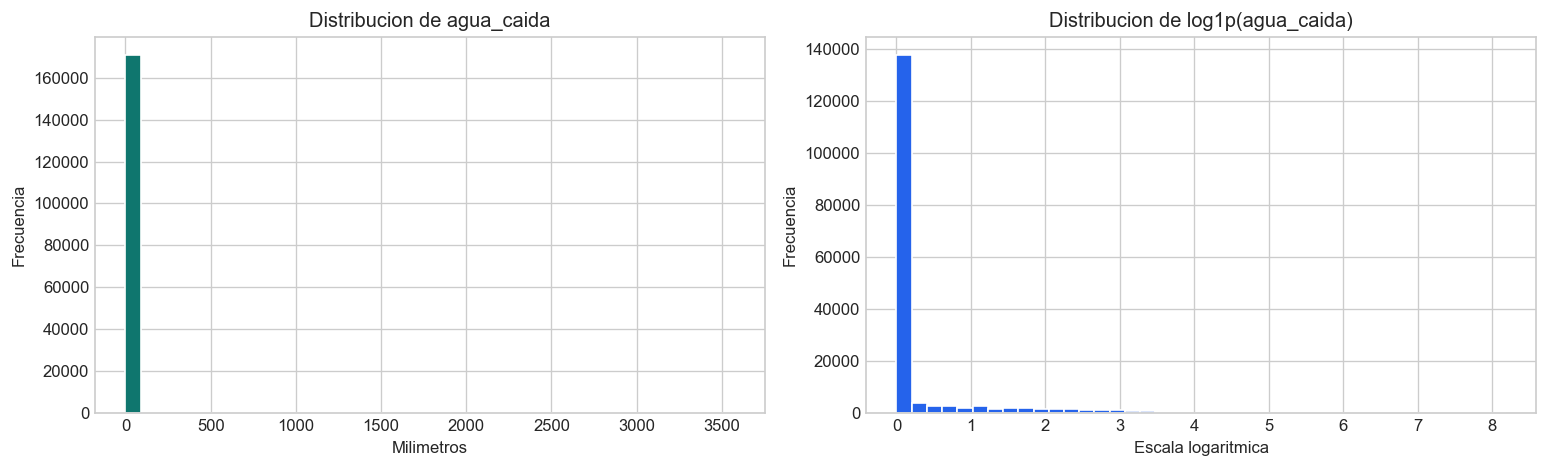

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["agua_caida"].dropna(), bins=40, color="#0f766e", edgecolor="white")
axes[0].set_title("Distribucion de agua_caida")
axes[0].set_xlabel("Milimetros")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["agua_caida"].dropna()), bins=40, color="#2563eb", edgecolor="white")
axes[1].set_title("Distribucion de log1p(agua_caida)")
axes[1].set_xlabel("Escala logaritmica")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Los histogramas muestran la forma global de la variable y dejan ver por que conviene trabajar tambien con una transformacion logaritmica. Para no mezclar todas las `zonas_climaticas` en una sola caja, el siguiente bloque separa los boxplots en subgraficos individuales; asi se aprecia mejor la dispersion propia de cada regimen territorial.


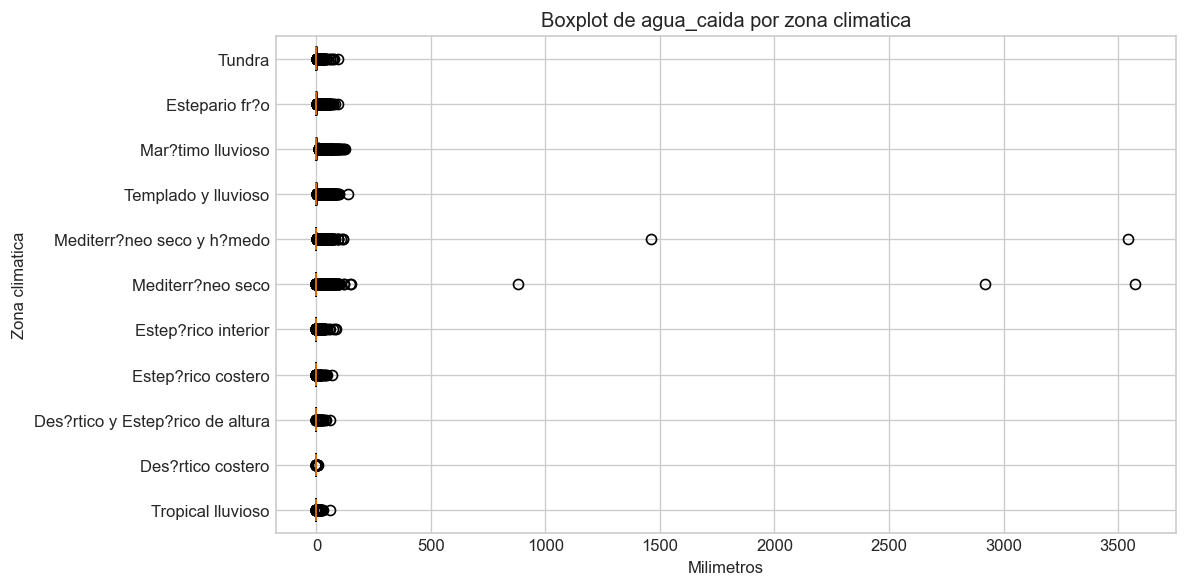

In [19]:
zonas_box = [zona for zona in ACTIVE_CLIMATE_ORDER if df.loc[df["zona_climatica"] == zona, "agua_caida"].notna().any()]
resumen_boxplots = pd.DataFrame(
    {
        "zona_climatica": zonas_box,
        "registros": [int(df.loc[df["zona_climatica"] == zona, "agua_caida"].notna().sum()) for zona in zonas_box],
        "mediana": [round(df.loc[df["zona_climatica"] == zona, "agua_caida"].median(), 2) for zona in zonas_box],
        "p95": [round(df.loc[df["zona_climatica"] == zona, "agua_caida"].quantile(0.95), 2) for zona in zonas_box],
    }
)

display(resumen_boxplots)

ncols = 2
nrows = int(np.ceil(len(zonas_box) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, zona in zip(axes, zonas_box):
    datos_zona = df.loc[df["zona_climatica"] == zona, "agua_caida"].dropna()
    ax.boxplot(
        datos_zona,
        vert=False,
        patch_artist=True,
        boxprops={"facecolor": CLIMATE_COLORS.get(zona, "#cbd5e1"), "alpha": 0.75},
        medianprops={"color": "#0f172a", "linewidth": 1.5},
        whiskerprops={"color": "#475569"},
        capprops={"color": "#475569"},
        flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#0f172a", "alpha": 0.2, "markeredgecolor": "none"},
    )
    ax.set_title(zona)
    ax.set_xlabel("Milimetros")
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.2)

for ax in axes[len(zonas_box):]:
    ax.axis("off")

fig.suptitle("Boxplots separados de agua_caida por zona climatica", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Para complementar la lectura de outliers, conviene mantener una visualizacion temporal, pero en un formato mas interpretable. En vez de mezclar todos los puntos en escala lineal, el siguiente bloque separa la lectura en dos paneles: a la izquierda se muestra la nube en escala logaritmica para recuperar visibilidad en los valores bajos y medios; a la derecha se muestran solo los eventos realmente extremos, es decir, aquellos ubicados sobre el percentil 99.


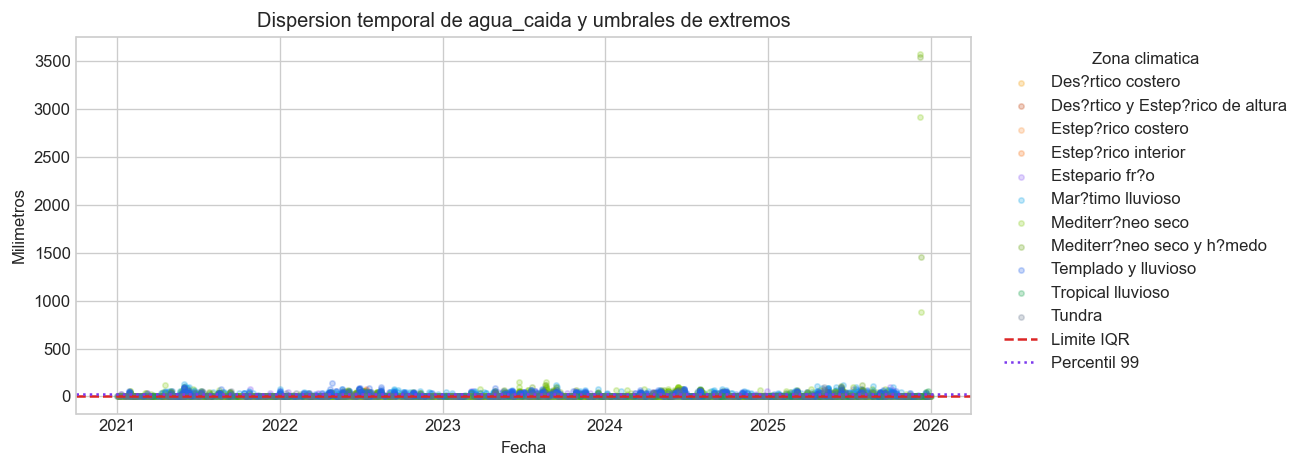

In [20]:
muestra_dispersion = df.loc[df["agua_caida"].notna(), ["fecha", "agua_caida", "zona_climatica"]].copy()

muestra_regular = muestra_dispersion.loc[muestra_dispersion["agua_caida"] < p95].sample(
    n=min(4000, int((muestra_dispersion["agua_caida"] < p95).sum())),
    random_state=42,
)
muestra_intermedia = muestra_dispersion.loc[
    (muestra_dispersion["agua_caida"] >= p95) & (muestra_dispersion["agua_caida"] < p99)
]
muestra_extrema = muestra_dispersion.loc[muestra_dispersion["agua_caida"] >= p99].sort_values("fecha")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

muestra_log = pd.concat([muestra_regular, muestra_intermedia, muestra_extrema], axis=0).sort_values("fecha")
for zona, subset in muestra_log.groupby("zona_climatica"):
    axes[0].scatter(
        subset["fecha"],
        subset["agua_caida"] + 0.1,
        s=np.where(subset["agua_caida"] >= p99, 16, 8),
        alpha=0.22,
        color=CLIMATE_COLORS.get(zona, "#94a3b8"),
        label=zona,
    )

axes[0].axhline(max(upper, 0.1), color="#dc2626", linestyle="--", linewidth=1.4, label="Limite IQR")
axes[0].axhline(max(p99, 0.1), color="#7c3aed", linestyle=":", linewidth=1.6, label="Percentil 99")
axes[0].set_yscale("log")
axes[0].set_title("Dispersion temporal en escala logaritmica")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Milimetros (escala log)")
axes[0].grid(alpha=0.2)

for zona, subset in muestra_extrema.groupby("zona_climatica"):
    axes[1].scatter(
        subset["fecha"],
        subset["agua_caida"],
        s=subset["agua_caida"].clip(upper=250) * 0.35,
        alpha=0.7,
        color=CLIMATE_COLORS.get(zona, "#94a3b8"),
        edgecolors="#0f172a",
        linewidth=0.4,
        label=zona,
    )

axes[1].axhline(p99, color="#7c3aed", linestyle=":", linewidth=1.6, label="Percentil 99")
axes[1].set_title("Eventos extremos (>= percentil 99)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Milimetros")
axes[1].grid(alpha=0.2)

handles, labels = axes[1].get_legend_handles_labels()
legend_items = dict(zip(labels, handles))
axes[1].legend(legend_items.values(), legend_items.keys(), title="Zona climatica", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


**Analisis.** La escala lineal original hacia muy dificil interpretar la nube completa, porque unos pocos eventos extremos comprimian visualmente al resto de los datos. Por eso no conviene reemplazar esos valores por la media: hacerlo borraria episodios reales de precipitacion intensa y distorsionaria la serie. La solucion mas coherente es conservar los extremos y cambiar la forma de mirarlos. El panel izquierdo, en escala logaritmica, deja ver mejor la masa principal de observaciones y confirma que el umbral IQR es demasiado bajo para una variable tan sesgada. El panel derecho se concentra solo en el percentil 99 y permite estudiar los episodios realmente excepcionales sin ocultar su magnitud. De este modo, los outliers se interpretan como eventos a revisar y modelar con cautela, no como errores que deban sustituirse por un promedio global.


### 2.4 Transformaciones


Sobre la base del diagnostico anterior, se define un conjunto de trabajo orientado al analisis. Esta etapa no busca todavia optimizar un modelo, sino dejar la informacion en una forma mas interpretable y util para las fases posteriores, manteniendo tanto la trazabilidad territorial como la secuencia temporal de los registros.


In [21]:
columnas_trabajo = [
    "codigo_estacion", "nombre_estacion", "region", "nombre_region", "zona_geografica",
    "macrozona", "zona_climatica", "altura", "latitud", "longitud", "anio", "mes", "dia", "fecha", "agua_caida"
]

df_trabajo = df[columnas_trabajo].copy()

print("Columnas seleccionadas para el trabajo analitico:")
display(pd.DataFrame({"columnas": df_trabajo.columns}))
display(df_trabajo.head())


Columnas seleccionadas para el trabajo analitico:


,columnas
0,codigo_estacion
1,nombre_estacion
2,region
3,nombre_region
4,zona_geografica
5,macrozona
6,zona_climatica
7,altura
8,latitud
9,longitud


,codigo_estacion,nombre_estacion,region,nombre_region,zona_geografica,macrozona,zona_climatica,altura,latitud,longitud,anio,mes,dia,fecha,agua_caida
0,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,1,2023-01-01,NaN
1,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,2,2023-01-02,NaN
2,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,3,2023-01-03,NaN
3,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,4,2023-01-04,NaN
4,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,Norte,Tropical lluvioso,4084,-17.595,-69.4775,2023,1,5,2023-01-05,NaN


**Analisis.** El conjunto de trabajo conserva tanto identificadores tecnicos como descriptores territoriales. A los pares `codigo_estacion`/`nombre_estacion` y `region`/`nombre_region` se suman `zona_geografica`, `macrozona` y `zona_climatica`, porque en esta entrega interesa comparar el comportamiento de la precipitacion en distintas escalas espaciales y no solo dejar una base minima para modelamiento.


#### 2.4.1 A numericos (Encoder)


Las variables categoricas nominales deben transformarse a una representacion numerica cuando se desea utilizarlas en procedimientos cuantitativos. Siguiendo el material de apoyo, la estrategia mas consistente en este caso es `one-hot encoding`, ya que no existe un orden natural entre regiones, zonas geograficas ni zonas climaticas. Sin embargo, conviene aplicar esta transformacion con criterio, porque atributos de muy alta cardinalidad, como la estacion, pueden multiplicar innecesariamente el numero de columnas.


In [22]:
df_encoder = pd.get_dummies(
    df_trabajo[["nombre_region", "zona_geografica", "zona_climatica"]],
    columns=["nombre_region", "zona_geografica", "zona_climatica"],
    drop_first=False,
    dtype=int,
)

print(f"Shape original de columnas categoricas seleccionadas: {df_trabajo[['nombre_region', 'zona_geografica', 'zona_climatica']].shape}")
print(f"Shape despues del encoding: {df_encoder.shape}")
display(df_encoder.head())


Shape original de columnas categoricas seleccionadas: (187876, 3)
Shape despues del encoding: (187876, 33)


,nombre_region_Antofagasta,nombre_region_Arica y Parinacota,nombre_region_Atacama,nombre_region_AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,nombre_region_Coquimbo,nombre_region_De La AraucanÃ­a,nombre_region_De Los Lagos,nombre_region_De Los RÃ­os,nombre_region_De Ãuble,nombre_region_Del BiobÃ­o,nombre_region_Del Libertador Gral. Bernardo O'Higgins,nombre_region_Del Maule,nombre_region_Magallanes y de la AntÃ¡rtica Chilena,nombre_region_Metropolitana de Santiago,nombre_region_TarapacÃ¡,nombre_region_ValparaÃ­so,zona_geografica_Cordillera,zona_geografica_Litoral,zona_geografica_PreCordillera,zona_geografica_Secano Costero,zona_geografica_Secano Interior,zona_geografica_Valle,zona_climatica_Des?rtico costero,zona_climatica_Des?rtico y Estep?rico de altura,zona_climatica_Estep?rico costero,zona_climatica_Estep?rico interior,zona_climatica_Estepario fr?o,zona_climatica_Mar?timo lluvioso,zona_climatica_Mediterr?neo seco,zona_climatica_Mediterr?neo seco y h?medo,zona_climatica_Templado y lluvioso,zona_climatica_Tropical lluvioso,zona_climatica_Tundra
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


**Analisis.** Se utiliza `one-hot encoding` porque `nombre_region`, `zona_geografica` y `zona_climatica` son categorias nominales sin jerarquia intrinseca. Esta decision evita imponer relaciones artificiales entre territorios. En esta fase no se codifica la estacion de manera exhaustiva, ya que su alta cardinalidad incrementaria considerablemente el numero de columnas y dificultaria la interpretacion inicial. Por lo tanto, se privilegia una codificacion territorial compacta y alineada con el objetivo de entendimiento de datos.


#### 2.4.2 Tratamiento de Nulos


Dado que los nulos se concentran en `agua_caida`, el tratamiento debe hacerse con cuidado para no perder informacion valiosa del territorio ni de la estacionalidad. En lugar de eliminar esos registros, se utilizara `KNNImputer`, apoyandose en predictores espaciales, temporales y categoricos codificados. Dentro de estos ultimos, la inclusion de la zona climatica ayuda a que la busqueda de vecinos considere similitud de regimen de lluvia y no solo cercania administrativa.


In [23]:
nulos_originales = int(df_trabajo["agua_caida"].isna().sum())
features_numericas_knn = df_trabajo[["altura", "latitud", "longitud", "anio", "mes", "dia"]].copy()

display(features_numericas_knn.head())


,altura,latitud,longitud,anio,mes,dia
0,4084,-17.595,-69.4775,2023,1,1
1,4084,-17.595,-69.4775,2023,1,2
2,4084,-17.595,-69.4775,2023,1,3
3,4084,-17.595,-69.4775,2023,1,4
4,4084,-17.595,-69.4775,2023,1,5


Las variables numericas entregan la base espacial y temporal del imputador. Luego se agregan variables categoricas codificadas para que la similitud entre observaciones no dependa solo de coordenadas o calendario, sino tambien del contexto territorial mas amplio.


In [24]:
features_categoricas_knn = pd.get_dummies(
    df_trabajo[["nombre_region", "zona_geografica", "zona_climatica"]],
    drop_first=False,
    dtype=float,
)

features_knn = pd.concat([features_numericas_knn, features_categoricas_knn], axis=1)


Este paso solo arma la matriz de apoyo para el KNN. Asi queda mas claro que una cosa es definir los predictores del imputador y otra distinta es resumir o evaluar el resultado posterior.


In [25]:
resumen_knn = pd.DataFrame(
    {
        "filas_totales": [len(df_trabajo)],
        "nulos_originales_agua_caida": [nulos_originales],
        "columnas_para_knn": [features_knn.shape[1]],
    }
)

display(resumen_knn)
display(features_knn.head())


,filas_totales,nulos_originales_agua_caida,columnas_para_knn
0,187876,17063,39


,altura,latitud,longitud,anio,mes,dia,nombre_region_Antofagasta,nombre_region_Arica y Parinacota,nombre_region_Atacama,nombre_region_AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,nombre_region_Coquimbo,nombre_region_De La AraucanÃ­a,nombre_region_De Los Lagos,nombre_region_De Los RÃ­os,nombre_region_De Ãuble,nombre_region_Del BiobÃ­o,nombre_region_Del Libertador Gral. Bernardo O'Higgins,nombre_region_Del Maule,nombre_region_Magallanes y de la AntÃ¡rtica Chilena,nombre_region_Metropolitana de Santiago,nombre_region_TarapacÃ¡,nombre_region_ValparaÃ­so,zona_geografica_Cordillera,zona_geografica_Litoral,zona_geografica_PreCordillera,zona_geografica_Secano Costero,zona_geografica_Secano Interior,zona_geografica_Valle,zona_climatica_Des?rtico costero,zona_climatica_Des?rtico y Estep?rico de altura,zona_climatica_Estep?rico costero,zona_climatica_Estep?rico interior,zona_climatica_Estepario fr?o,zona_climatica_Mar?timo lluvioso,zona_climatica_Mediterr?neo seco,zona_climatica_Mediterr?neo seco y h?medo,zona_climatica_Templado y lluvioso,zona_climatica_Tropical lluvioso,zona_climatica_Tundra
0,4084,-17.595,-69.4775,2023,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,4084,-17.595,-69.4775,2023,1,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4084,-17.595,-69.4775,2023,1,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4084,-17.595,-69.4775,2023,1,4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4084,-17.595,-69.4775,2023,1,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


En esta primera parte se define la informacion que el algoritmo usara para buscar vecinos similares. La idea es que cada imputacion considere al mismo tiempo calendario, posicion geografica, relieve y contexto territorial, en vez de reemplazar los nulos con una media global demasiado simplificada.


In [26]:
matriz_knn = pd.concat([features_knn, df_trabajo[["agua_caida"]]], axis=1)
columnas_escaladas = ["altura", "latitud", "longitud", "anio", "mes", "dia"]
medias = matriz_knn[columnas_escaladas].mean()
desv = matriz_knn[columnas_escaladas].std(ddof=0).replace(0, 1)


La estandarizacion se separa en una celda propia porque es una decision metodologica importante. Sin este paso, variables como `altura` o `latitud` podrian dominar el calculo de distancias solo por su escala numerica y sesgar la seleccion de vecinos del KNN.


In [27]:
matriz_knn_escalada = matriz_knn.copy()
matriz_knn_escalada[columnas_escaladas] = (
    (matriz_knn_escalada[columnas_escaladas] - medias) / desv
)

display(matriz_knn_escalada[columnas_escaladas + ["agua_caida"]].head())


,altura,latitud,longitud,anio,mes,dia,agua_caida
0,4.913609,2.061308,0.530065,-0.038953,-1.598298,-1.673059,NaN
1,4.913609,2.061308,0.530065,-0.038953,-1.598298,-1.559408,NaN
2,4.913609,2.061308,0.530065,-0.038953,-1.598298,-1.445756,NaN
3,4.913609,2.061308,0.530065,-0.038953,-1.598298,-1.332105,NaN
4,4.913609,2.061308,0.530065,-0.038953,-1.598298,-1.218453,NaN


En esta celda todavia no se imputa nada: solo se deja la matriz en una escala comparable para que el KNN mida distancias de manera mas equilibrada. Una vez estandarizados esos predictores, la celda siguiente ejecuta el imputador y vuelca el resultado de regreso a `df_modelo`.


In [28]:
imputador_knn = KNNImputer(n_neighbors=5, weights="distance")
matriz_knn_imputada = pd.DataFrame(
    imputador_knn.fit_transform(matriz_knn_escalada),
    columns=matriz_knn_escalada.columns,
    index=matriz_knn_escalada.index,
)

df_modelo = df_trabajo.copy()
df_modelo["agua_caida_imputada"] = df_modelo["agua_caida"].isna().astype(int)
df_modelo["agua_caida"] = matriz_knn_imputada["agua_caida"].clip(lower=0)


Una vez entrenado el `KNNImputer`, los valores imputados se vuelcan de regreso a `df_modelo`. Aqui todavia no se interpreta el resultado; solo se deja construida la base analitica completa con su marca de imputacion.


In [29]:
resumen_limpieza_nulos = pd.DataFrame(
    {
        "filas_totales": [len(df_modelo)],
        "nulos_originales_agua_caida": [nulos_originales],
        "nulos_restantes_agua_caida": [int(df_modelo["agua_caida"].isna().sum())],
        "porcentaje_imputado": [round(df_modelo["agua_caida_imputada"].mean() * 100, 2)],
        "k_vecinos": [5],
    }
)

display(resumen_limpieza_nulos)


,filas_totales,nulos_originales_agua_caida,nulos_restantes_agua_caida,porcentaje_imputado,k_vecinos
0,187876,17063,0,9.08,5


Despues de aplicar el imputador, la base queda completa y se conserva la totalidad de las filas. La columna `agua_caida_imputada` es importante porque deja trazabilidad sobre que registros provienen de observacion real y cuales fueron estimados.


In [30]:
comparacion_imputacion = pd.DataFrame(
    {
        "grupo": ["Valores observados", "Valores imputados KNN"],
        "media": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].mean(), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].mean(), 2),
        ],
        "mediana": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].median(), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].median(), 2),
        ],
        "p95": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].quantile(0.95), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].quantile(0.95), 2),
        ],
    }
)

display(comparacion_imputacion)


,grupo,media,mediana,p95
0,Valores observados,1.49,0.00,8.60
1,Valores imputados KNN,2.16,0.03,10.51


Esta comparacion separa estadisticamente los valores observados de los imputados. Si ambos grupos quedan en rangos parecidos, la imputacion resulta mas defendible; si se alejan demasiado, conviene revisar el criterio antes de seguir modelando.


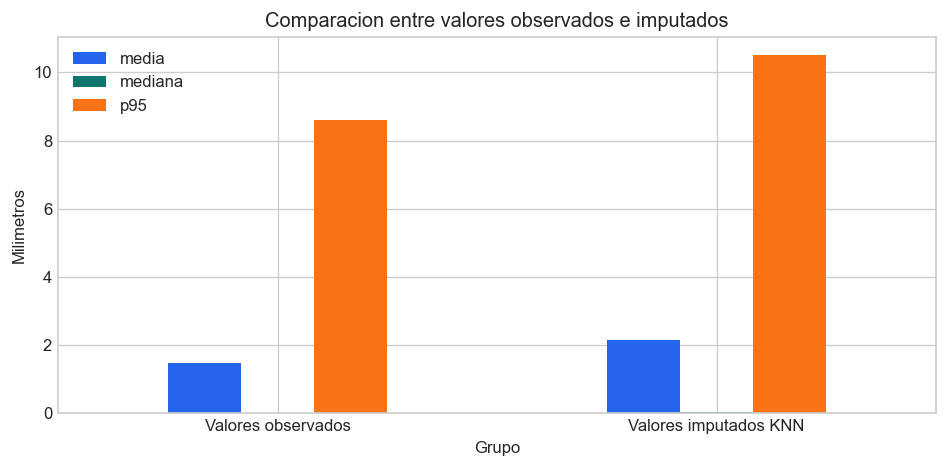

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
comparacion_imputacion.set_index("grupo")[["media", "mediana", "p95"]].plot(
    kind="bar", ax=ax, color=["#2563eb", "#0f766e", "#f97316"]
)
ax.set_title("Comparacion entre valores observados e imputados")
ax.set_xlabel("Grupo")
ax.set_ylabel("Milimetros")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


**Analisis.** El uso de `KNNImputer` permite conservar la totalidad de las filas y reemplazar los faltantes de `agua_caida` a partir de observaciones cercanas en terminos de ubicacion, calendario y contexto territorial. La comparacion entre valores observados e imputados permite verificar si las estimaciones quedan dentro de un rango razonable. Aun asi, este tipo de imputacion tiende a suavizar extremos, por lo que conviene mantener la marca `agua_caida_imputada` y considerar esa diferencia en fases posteriores del modelamiento.


#### 2.4.3 Tratamiento de Outliers


En un problema climaticamente variable, eliminar outliers de manera automatica puede implicar la perdida de eventos relevantes. En consecuencia, se adopta una estrategia conservadora: mantener los registros, crear una transformacion logaritmica que reduzca la asimetria y agregar marcas que permitan identificar eventos extremos para revisiones posteriores.


In [32]:
umbral_extremo_p99 = df_modelo["agua_caida"].quantile(0.99)

df_modelo["agua_caida_log"] = np.log1p(df_modelo["agua_caida"])
df_modelo["evento_extremo_p99"] = (df_modelo["agua_caida"] >= umbral_extremo_p99).astype(int)
df_modelo["revision_manual_mayor_100"] = (df_modelo["agua_caida"] > 100).astype(int)

display(
    df_modelo[["agua_caida", "agua_caida_log", "evento_extremo_p99", "revision_manual_mayor_100"]].head()
)


,agua_caida,agua_caida_log,evento_extremo_p99,revision_manual_mayor_100
0,2.510495,1.255757,0,0
1,2.076567,1.123814,0,0
2,1.074823,0.729876,0,0
3,1.200949,0.788889,0,0
4,1.265519,0.817804,0,0


Primero se crean variables auxiliares que no eliminan informacion, sino que la vuelven mas manejable. La transformacion logaritmica reduce la asimetria, mientras que los indicadores binarios separan registros usuales de episodios intensos.


In [33]:
comparacion_escala = df_modelo[["agua_caida", "agua_caida_log"]].describe().T.round(2)
resumen_extremos = pd.DataFrame(
    {
        "umbral_p99": [round(umbral_extremo_p99, 2)],
        "eventos_extremos_p99": [int(df_modelo["evento_extremo_p99"].sum())],
        "registros_mayores_100mm": [int(df_modelo["revision_manual_mayor_100"].sum())],
        "registros_mayores_500mm": [int((df_modelo["agua_caida"] > 500).sum())],
    }
)

display(comparacion_escala)
display(resumen_extremos)


,count,mean,std,min,25%,50%,75%,max
agua_caida,187876.0,1.55,15.56,0.0,0.0,0.0,0.1,3574.30
agua_caida_log,187876.0,0.34,0.77,0.0,0.0,0.0,0.1,8.18


,umbral_p99,eventos_extremos_p99,registros_mayores_100mm,registros_mayores_500mm
0,27.0,1890,25,8


**Analisis.** La estrategia seleccionada no elimina precipitaciones extremas, sino que conserva los registros y los hace mas manejables desde el punto de vista analitico. La transformacion `log1p` reduce la dispersion de la variable y facilita posteriores comparaciones, mientras que `evento_extremo_p99` permite identificar observaciones inusuales sin expulsarlas del conjunto. Este enfoque es mas consistente con la naturaleza del problema, ya que los eventos poco frecuentes forman parte del fenomeno estudiado.


### 2.5 Analisis estadisticos basicos


Una vez revisada la calidad general del dataset, corresponde resumir sus principales estadisticas descriptivas. En esta subseccion se examinan tanto las variables numericas base como la forma en que la precipitacion cambia entre zonas climaticas, estaciones, zonas geograficas y regiones, con el fin de caracterizar el comportamiento general del conjunto antes de avanzar a correlaciones y construccion de nuevas variables.


In [34]:
estadisticas_numericas = (
    df_modelo[["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida", "agua_caida_log"]]
    .describe()
    .T
    .round(2)
)

display(estadisticas_numericas)


,count,mean,std,min,25%,50%,75%,max
altura,187876.0,441.95,741.22,5.00,53.00,156.00,474.00,4084.00
latitud,187876.0,-35.85,8.86,-62.19,-40.08,-33.73,-32.22,-17.60
longitud,187876.0,-71.69,4.18,-109.43,-72.34,-71.19,-70.68,-58.98
anio,187876.0,2023.05,1.41,2021.00,2022.00,2023.00,2024.00,2025.00
mes,187876.0,6.51,3.44,1.00,4.00,7.00,9.00,12.00
dia,187876.0,15.72,8.80,1.00,8.00,16.00,23.00,31.00
agua_caida,187876.0,1.55,15.56,0.00,0.00,0.00,0.10,3574.30
agua_caida_log,187876.0,0.34,0.77,0.00,0.00,0.00,0.10,8.18


Este bloque resume el comportamiento global de las variables numericas. En especial, interesa comparar media, mediana y maximos de `agua_caida` para verificar cuan asimetrica sigue siendo la distribucion incluso despues del tratamiento de nulos y de la creacion de `agua_caida_log`.


In [35]:
resumen_climatico = (
    df_modelo.groupby("zona_climatica")
    .agg(
        estaciones=("nombre_estacion", "nunique"),
        regiones=("nombre_region", "nunique"),
        zonas_geograficas=("zona_geografica", "nunique"),
        media_lluvia=("agua_caida", "mean"),
        mediana_lluvia=("agua_caida", "median"),
        maximo_lluvia=("agua_caida", "max"),
        frecuencia_lluvia=("agua_caida", lambda s: (s > 0).mean() * 100),
    )
    .reindex(ACTIVE_CLIMATE_ORDER)
    .round(2)
)

display(resumen_climatico)


,estaciones,regiones,zonas_geograficas,media_lluvia,mediana_lluvia,maximo_lluvia,frecuencia_lluvia
zona_climatica,,,,,,,
Tropical lluvioso,3,2,2,0.53,0.00,58.5,19.34
Des?rtico costero,8,3,1,0.00,0.00,5.2,0.60
Des?rtico y Estep?rico de altura,4,2,2,0.13,0.00,61.1,4.19
Estep?rico costero,3,2,1,0.16,0.00,67.1,6.97
Estep?rico interior,8,2,1,0.19,0.00,84.9,6.06
Mediterr?neo seco,39,4,6,0.99,0.00,3574.3,17.83
Mediterr?neo seco y h?medo,8,2,3,2.94,0.00,3541.5,34.20
Templado y lluvioso,12,3,2,3.05,0.04,136.4,50.76
Mar?timo lluvioso,10,4,1,4.06,0.40,126.8,61.68


Luego se cambia la lectura puramente agregada por una vista con recuentos observados. En vez de quedarse solo con promedios, esta figura muestra cuantas filas reales aporta cada combinacion de `zona_climatica` y `macrozona`, cuantos dias con lluvia concentra y cuantas estaciones participan en esa clase territorial.


,zona_climatica,macrozona,registros,dias_con_lluvia,porcentaje_lluvia,estaciones
0,Des?rtico costero,Norte,14604,87,0.6,8
1,Des?rtico y Estep?rico de altura,Norte,6795,285,4.2,4
2,Estep?rico costero,Norte,5451,380,7.0,3
3,Estep?rico interior,Norte,12673,768,6.1,8
10,Tropical lluvioso,Norte,4018,777,19.3,3
5,Mar?timo lluvioso,Austral,4959,3053,61.6,3
8,Mediterr?neo seco y h?medo,Sur,13147,4496,34.2,8
11,Tundra,Austral,12773,6049,47.4,7
4,Estepario fr?o,Austral,12052,6187,51.3,7
6,Mar?timo lluvioso,Sur,12782,7889,61.7,7


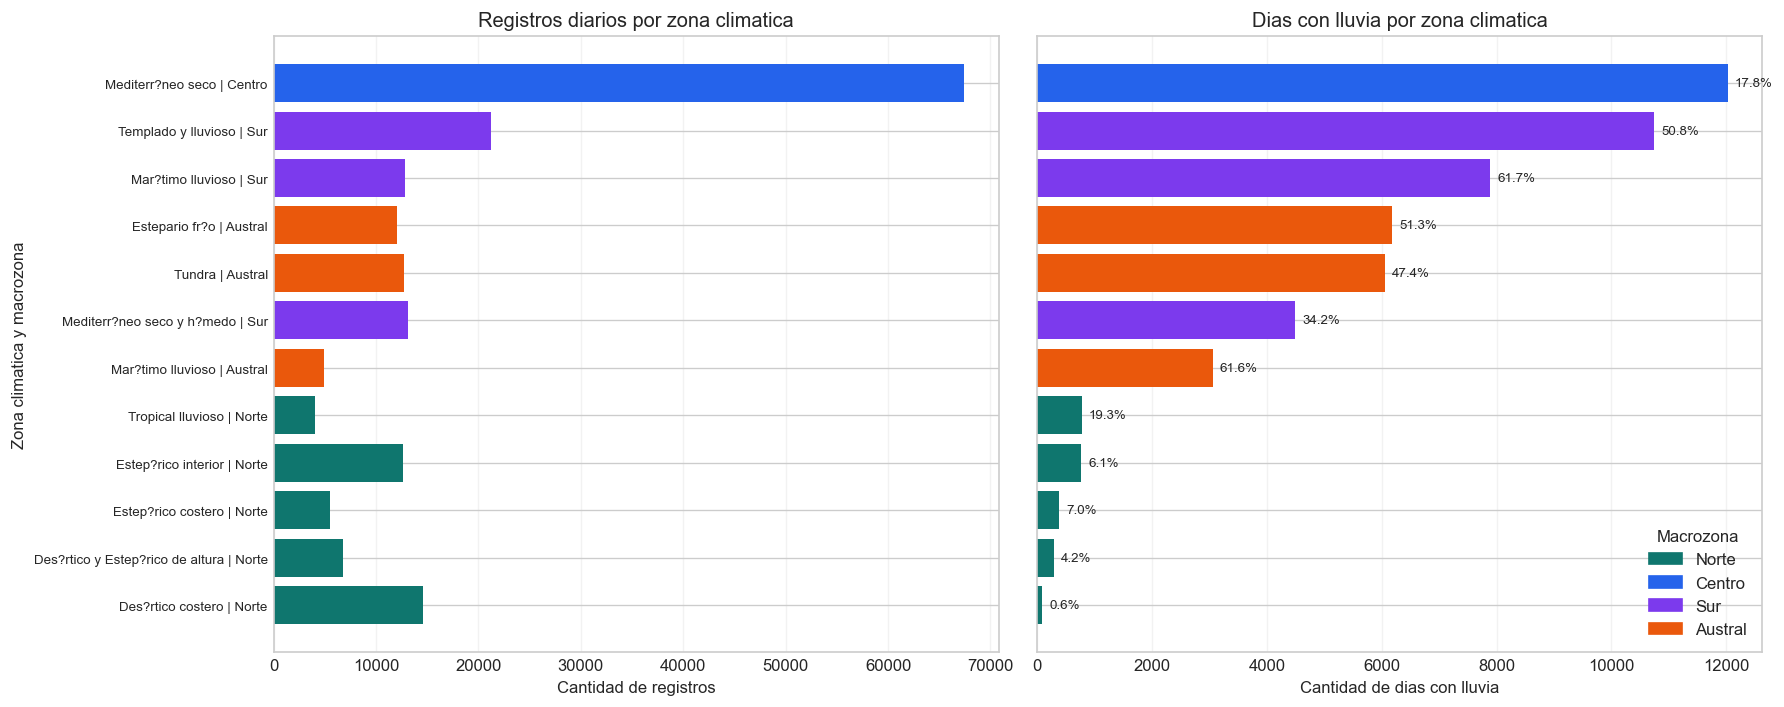

In [36]:
resumen_climatico_dispersion = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby(["zona_climatica", "macrozona"])
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        estaciones=("nombre_estacion", "nunique"),
    )
    .reset_index()
)

resumen_climatico_dispersion["porcentaje_lluvia"] = (
    resumen_climatico_dispersion["dias_con_lluvia"]
    .div(resumen_climatico_dispersion["registros"])
    .mul(100)
    .round(1)
)
resumen_climatico_dispersion["etiqueta"] = (
    resumen_climatico_dispersion["zona_climatica"]
    + " | "
    + resumen_climatico_dispersion["macrozona"]
)
resumen_climatico_dispersion = resumen_climatico_dispersion.sort_values(
    ["dias_con_lluvia", "registros"],
    ascending=True,
)

display(
    resumen_climatico_dispersion[[
        "zona_climatica", "macrozona", "registros", "dias_con_lluvia", "porcentaje_lluvia", "estaciones"
    ]]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
bar_colors = resumen_climatico_dispersion["macrozona"].map(MACROZONE_COLORS)

y_pos = np.arange(len(resumen_climatico_dispersion))
axes[0].barh(y_pos, resumen_climatico_dispersion["registros"], color=bar_colors)
axes[0].set_title("Registros diarios por zona climatica")
axes[0].set_xlabel("Cantidad de registros")
axes[0].set_ylabel("Zona climatica y macrozona")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(resumen_climatico_dispersion["etiqueta"], fontsize=8)
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(y_pos, resumen_climatico_dispersion["dias_con_lluvia"], color=bar_colors)
axes[1].set_title("Dias con lluvia por zona climatica")
axes[1].set_xlabel("Cantidad de dias con lluvia")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(resumen_climatico_dispersion["etiqueta"], fontsize=8)
axes[1].grid(axis="x", alpha=0.25)

for idx, (_, row) in enumerate(resumen_climatico_dispersion.iterrows()):
    axes[1].text(
        row["dias_con_lluvia"] + max(resumen_climatico_dispersion["dias_con_lluvia"]) * 0.01,
        idx,
        f'{row["porcentaje_lluvia"]:.1f}%',
        va="center",
        fontsize=8,
    )

macro_handles = [
    Patch(color=MACROZONE_COLORS[mz], label=mz)
    for mz in MACROZONE_ORDER
    if mz in resumen_climatico_dispersion["macrozona"].unique()
]
axes[1].legend(handles=macro_handles, title="Macrozona", loc="lower right")

plt.tight_layout()
plt.show()


**Analisis.** Esta version compara mejor cada clase territorial porque separa dos preguntas distintas: cuanta informacion aporta cada zona y cuantos dias con lluvia concentra realmente. Al usar barras horizontales, los nombres largos siguen siendo legibles y la macrozona queda clara mediante el color. Ademas, el porcentaje anotado al costado permite distinguir zonas con muchos registros pero baja frecuencia de lluvia respecto de otras con menos observaciones, pero una ocurrencia relativamente mayor del fenomeno.

### 2.6 Matriz de Correlacion


La correlacion inicial se calcula primero sobre variables numericas en bruto y utilizando el coeficiente de Pearson, tal como se revisa en el material de apoyo. Sin embargo, en esta entrega no conviene quedarse solo con una matriz global, porque las relaciones pueden cambiar bastante entre `Litoral`, `Valle`, `Cordillera`, `PreCordillera` y las demas `zonas_geograficas`. Por eso se presenta una matriz general y luego una version separada por cada zona geografica.


In [37]:
columnas_corr_inicial = ["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida"]

corr_inicial = df_modelo[columnas_corr_inicial].corr(numeric_only=True).round(3)

corr_inicial_por_zona = {
    zona: (
        df_modelo.loc[df_modelo["zona_geografica"] == zona, columnas_corr_inicial]
        .corr(numeric_only=True)
        .round(3)
    )
    for zona in ACTIVE_GEO_ORDER
}

resumen_corr_inicial_zona = pd.DataFrame(
    {
        zona: matriz["agua_caida"].drop("agua_caida")
        for zona, matriz in corr_inicial_por_zona.items()
    }
).T.round(3)

resumen_corr_inicial_zona.index.name = "zona_geografica"

display(corr_inicial)
display(corr_inicial["agua_caida"].sort_values(ascending=False))
display(resumen_corr_inicial_zona)


,altura,latitud,longitud,anio,mes,dia,agua_caida
altura,1.000,0.393,0.182,0.043,-0.002,-0.000,-0.028
latitud,0.393,1.000,-0.062,0.013,-0.002,-0.000,-0.047
longitud,0.182,-0.062,1.000,0.006,-0.001,-0.000,-0.027
anio,0.043,0.013,0.006,1.000,0.005,0.001,0.012
mes,-0.002,-0.002,-0.001,0.005,1.000,0.010,0.010
dia,-0.000,-0.000,-0.000,0.001,0.010,1.000,-0.006
agua_caida,-0.028,-0.047,-0.027,0.012,0.010,-0.006,1.000


agua_caida    1.000
anio          0.012
mes           0.010
dia          -0.006
longitud     -0.027
altura       -0.028
latitud      -0.047
Name: agua_caida, dtype: float64

,altura,latitud,longitud,anio,mes,dia
zona_geografica,,,,,,
Cordillera,0.165,0.092,-0.041,0.047,-0.065,0.015
Litoral,-0.023,-0.040,-0.025,0.014,0.010,-0.009
PreCordillera,-0.018,-0.021,-0.014,0.020,0.021,-0.010
Secano Costero,-0.045,-0.082,-0.074,0.016,0.011,0.008
Secano Interior,0.059,-0.059,-0.059,-0.003,0.004,0.002
Valle,-0.114,-0.145,-0.188,0.015,0.011,-0.001


La celda anterior produce tanto la matriz global como un resumen de la correlacion de `agua_caida` por `zona_geografica`. Los heatmaps siguientes traducen ese resultado a una lectura visual mas directa, separando la estructura nacional de las diferencias territoriales mas finas.


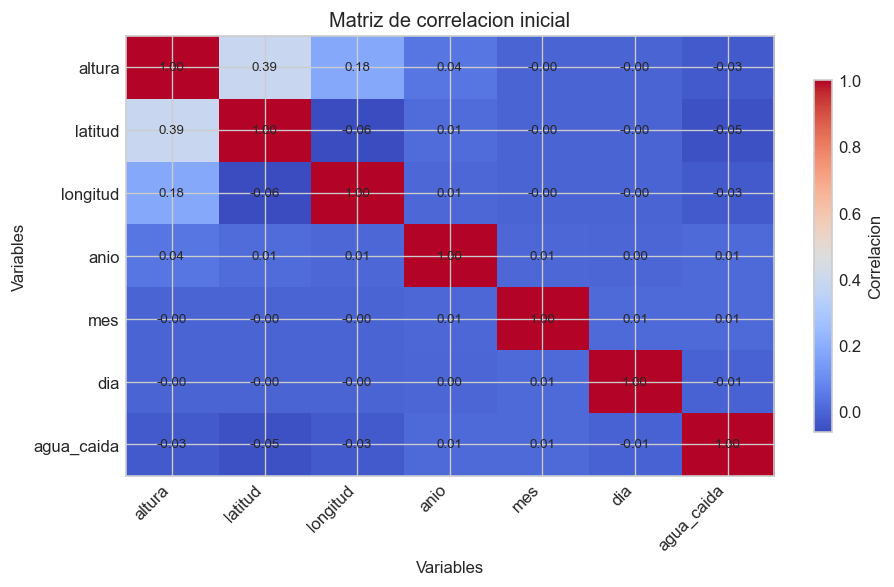

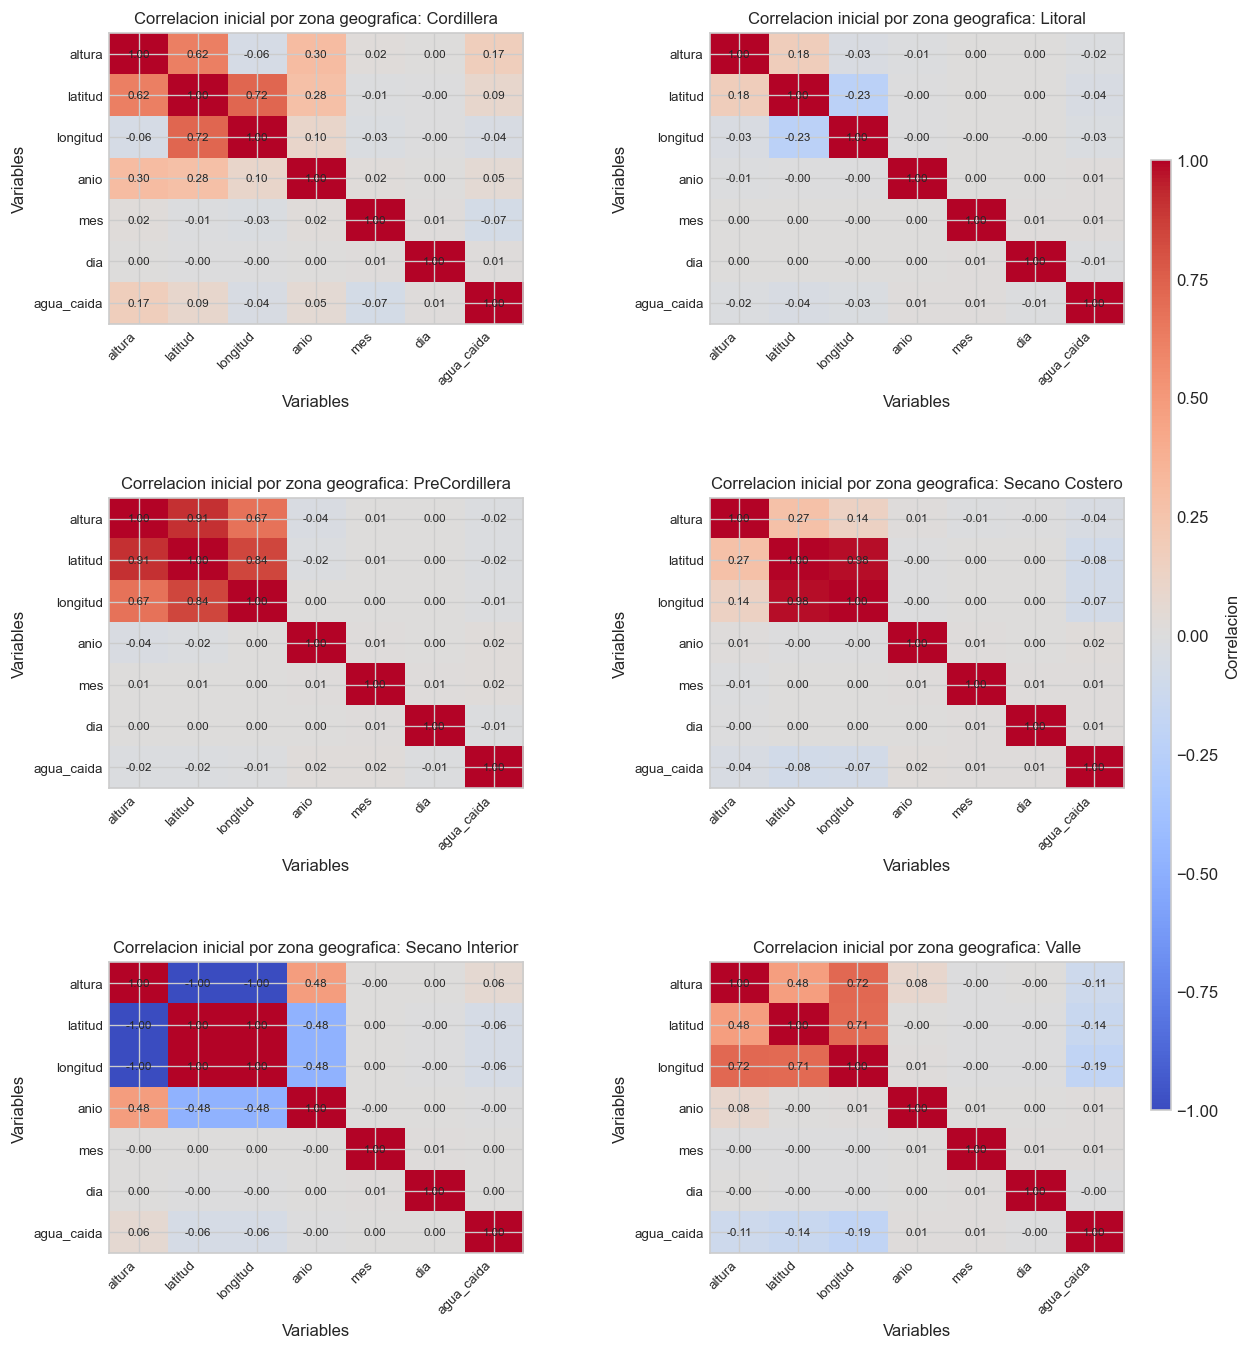

In [38]:
heatmap_df(
    corr_inicial,
    "Matriz de correlacion inicial",
    cmap="coolwarm",
    figsize=(8, 5),
    decimals=2,
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)

plot_group_heatmaps(
    corr_inicial_por_zona,
    "Correlacion inicial por zona geografica",
    cmap="coolwarm",
    decimals=2,
    ncols=2,
    base_figsize=(5.6, 4.4),
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)


**Analisis.** La matriz global sigue mostrando relaciones lineales debiles entre `agua_caida` y las variables numericas brutas, pero la lectura por `zona_geografica` agrega un matiz importante: la direccion y magnitud de algunas asociaciones cambia cuando se separa el territorio. Esto es esperable en Chile, porque `Litoral`, `Valle`, `PreCordillera` o `Cordillera` no responden al mismo regimen atmosferico ni a la misma topografia. Metodologicamente, esta desagregacion fortalece el analisis porque evita concluir que "no hay relacion" solo por haber mezclado espacios muy distintos dentro de una sola correlacion nacional.


La correlacion global sirve como punto de partida, pero puede ocultar diferencias territoriales importantes. Por eso se recalcula la matriz numerica separando el dataset por `macrozona`, `zona_geografica` y `zona_climatica`, manteniendo exactamente las mismas variables base. Asi se puede verificar si la asociacion entre altura, posicion y precipitaci?n cambia cuando se respeta la estructura espacial del pais.


In [39]:
columnas_corr_segmentada = ["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida"]

corr_por_macrozona = build_group_corr_dict(
    df_modelo, "macrozona", columnas_corr_segmentada, group_order=MACROZONE_ORDER, min_rows=100
)
corr_por_zona_geografica = build_group_corr_dict(
    df_modelo, "zona_geografica", columnas_corr_segmentada, group_order=ACTIVE_GEO_ORDER, min_rows=100
)
corr_por_zona_climatica = build_group_corr_dict(
    df_modelo, "zona_climatica", columnas_corr_segmentada, group_order=ACTIVE_CLIMATE_ORDER, min_rows=100
)


Antes de dibujar las matrices segmentadas conviene dejar una tabla que haga visible cuantas filas aporta cada subconjunto. Ese control de tamano es importante porque evita interpretar igual una macrozona muy representada y una categoria con menos soporte empirico.


In [40]:
resumen_segmentos_corr = pd.DataFrame(
    {
        "grupo": (
            [f"Macrozona: {grupo}" for grupo in corr_por_macrozona]
            + [f"Zona geografica: {grupo}" for grupo in corr_por_zona_geografica]
            + [f"Zona climatica: {grupo}" for grupo in corr_por_zona_climatica]
        ),
        "filas_utilizadas": (
            [int(df_modelo["macrozona"].eq(grupo).sum()) for grupo in corr_por_macrozona]
            + [int(df_modelo["zona_geografica"].eq(grupo).sum()) for grupo in corr_por_zona_geografica]
            + [int(df_modelo["zona_climatica"].eq(grupo).sum()) for grupo in corr_por_zona_climatica]
        ),
    }
)

display(resumen_segmentos_corr)


,grupo,filas_utilizadas
0,Macrozona: Norte,43541
1,Macrozona: Centro,67445
2,Macrozona: Sur,47106
3,Macrozona: Austral,29784
4,Zona geografica: Cordillera,7527
5,Zona geografica: Litoral,64838
6,Zona geografica: PreCordillera,19060
7,Zona geografica: Secano Costero,7277
8,Zona geografica: Secano Interior,2557
9,Zona geografica: Valle,86617


El resumen anterior deja trazabilidad sobre el tamano de cada grupo. De ese modo, las matrices no se interpretan como casos aislados, sino como patrones obtenidos sobre subconjuntos con respaldo suficiente de observaciones diarias.


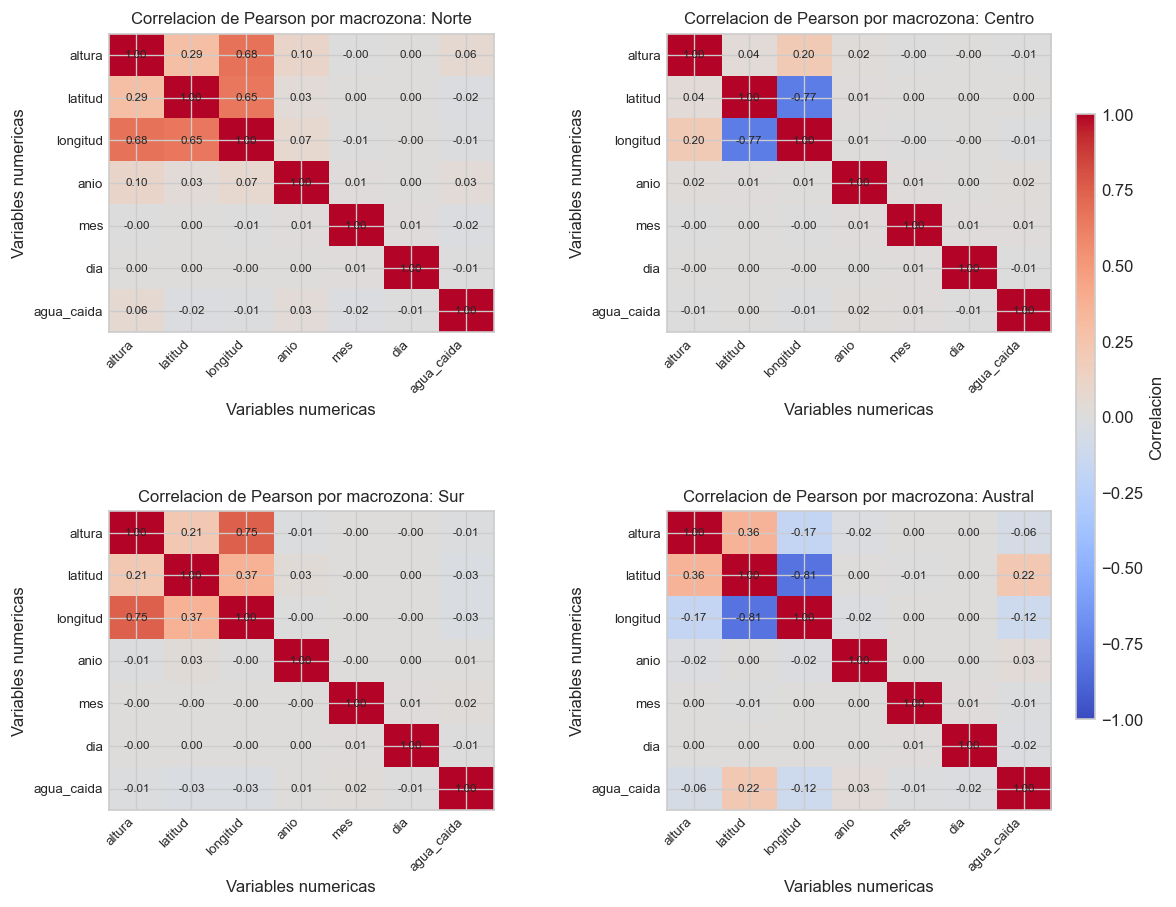

In [41]:
plot_group_heatmaps(
    corr_por_macrozona,
    "Correlacion de Pearson por macrozona",
    ncols=2,
    base_figsize=(5.2, 4.2),
    xlabel="Variables numericas",
    ylabel="Variables numericas",
    cbar_label="Correlacion"
)


La primera desagregacion se hace por `macrozona`, porque permite comparar grandes franjas del pais sin perder demasiada estabilidad estadistica. Es una buena escala intermedia entre la lectura totalmente nacional y el detalle territorial mas fino.


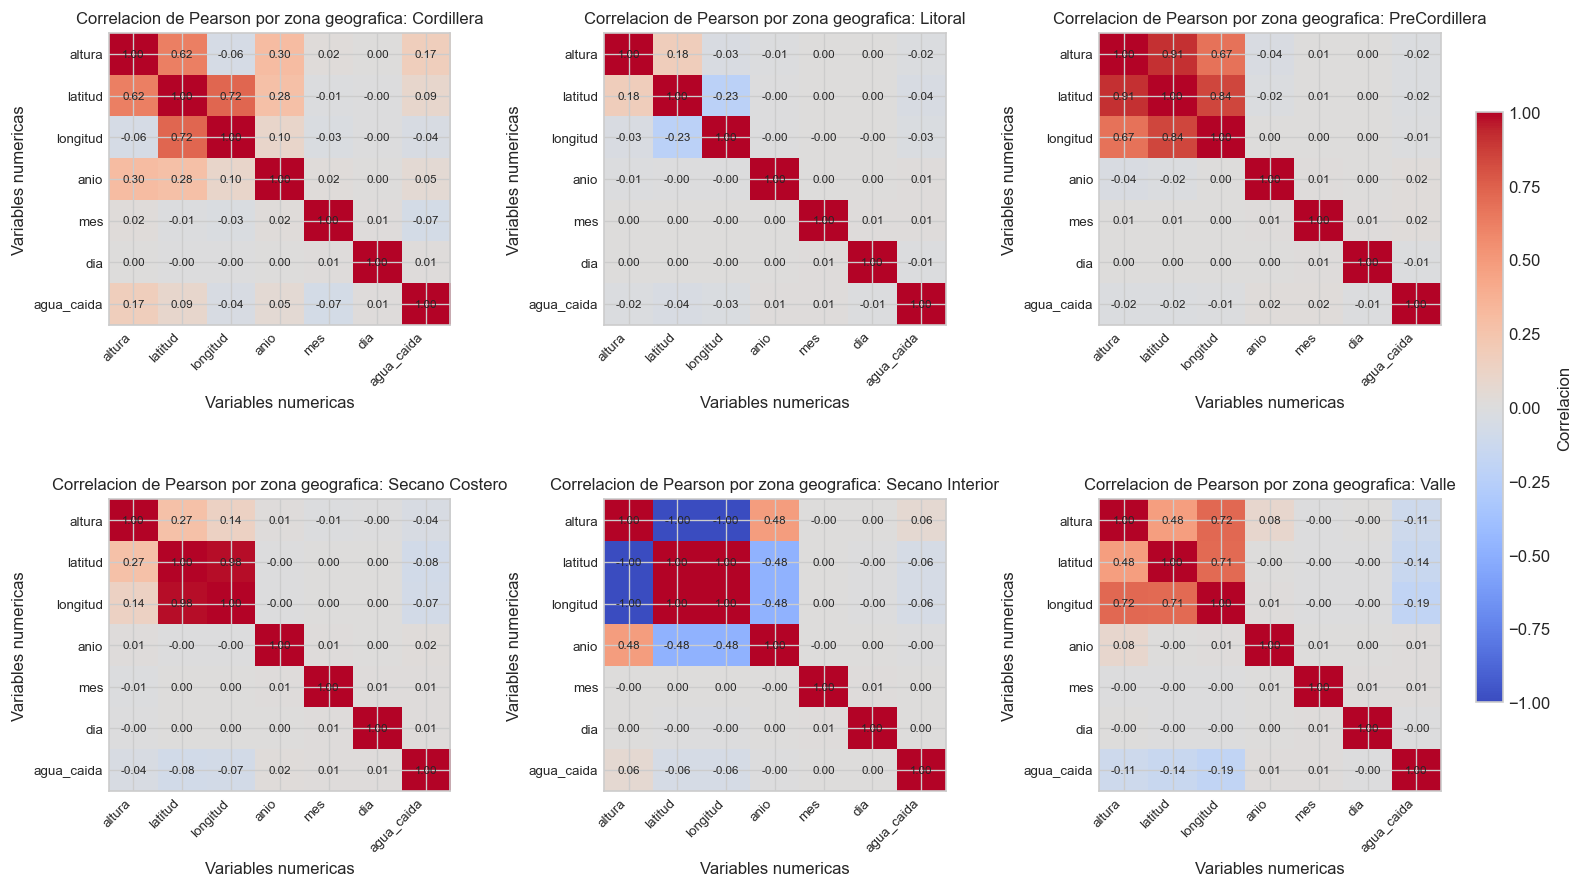

In [42]:
plot_group_heatmaps(
    corr_por_zona_geografica,
    "Correlacion de Pearson por zona geografica",
    ncols=3,
    base_figsize=(4.9, 4.1),
    xlabel="Variables numericas",
    ylabel="Variables numericas",
    cbar_label="Correlacion"
)


Luego la correlacion se revisa por `zona_geografica`. Aqui la idea es observar si el relieve y la posicion topografica modifican la relacion entre precipitaci?n y variables espaciales, algo esperable en un pais con costa, valle, cordillera y sectores de secano bien diferenciados.


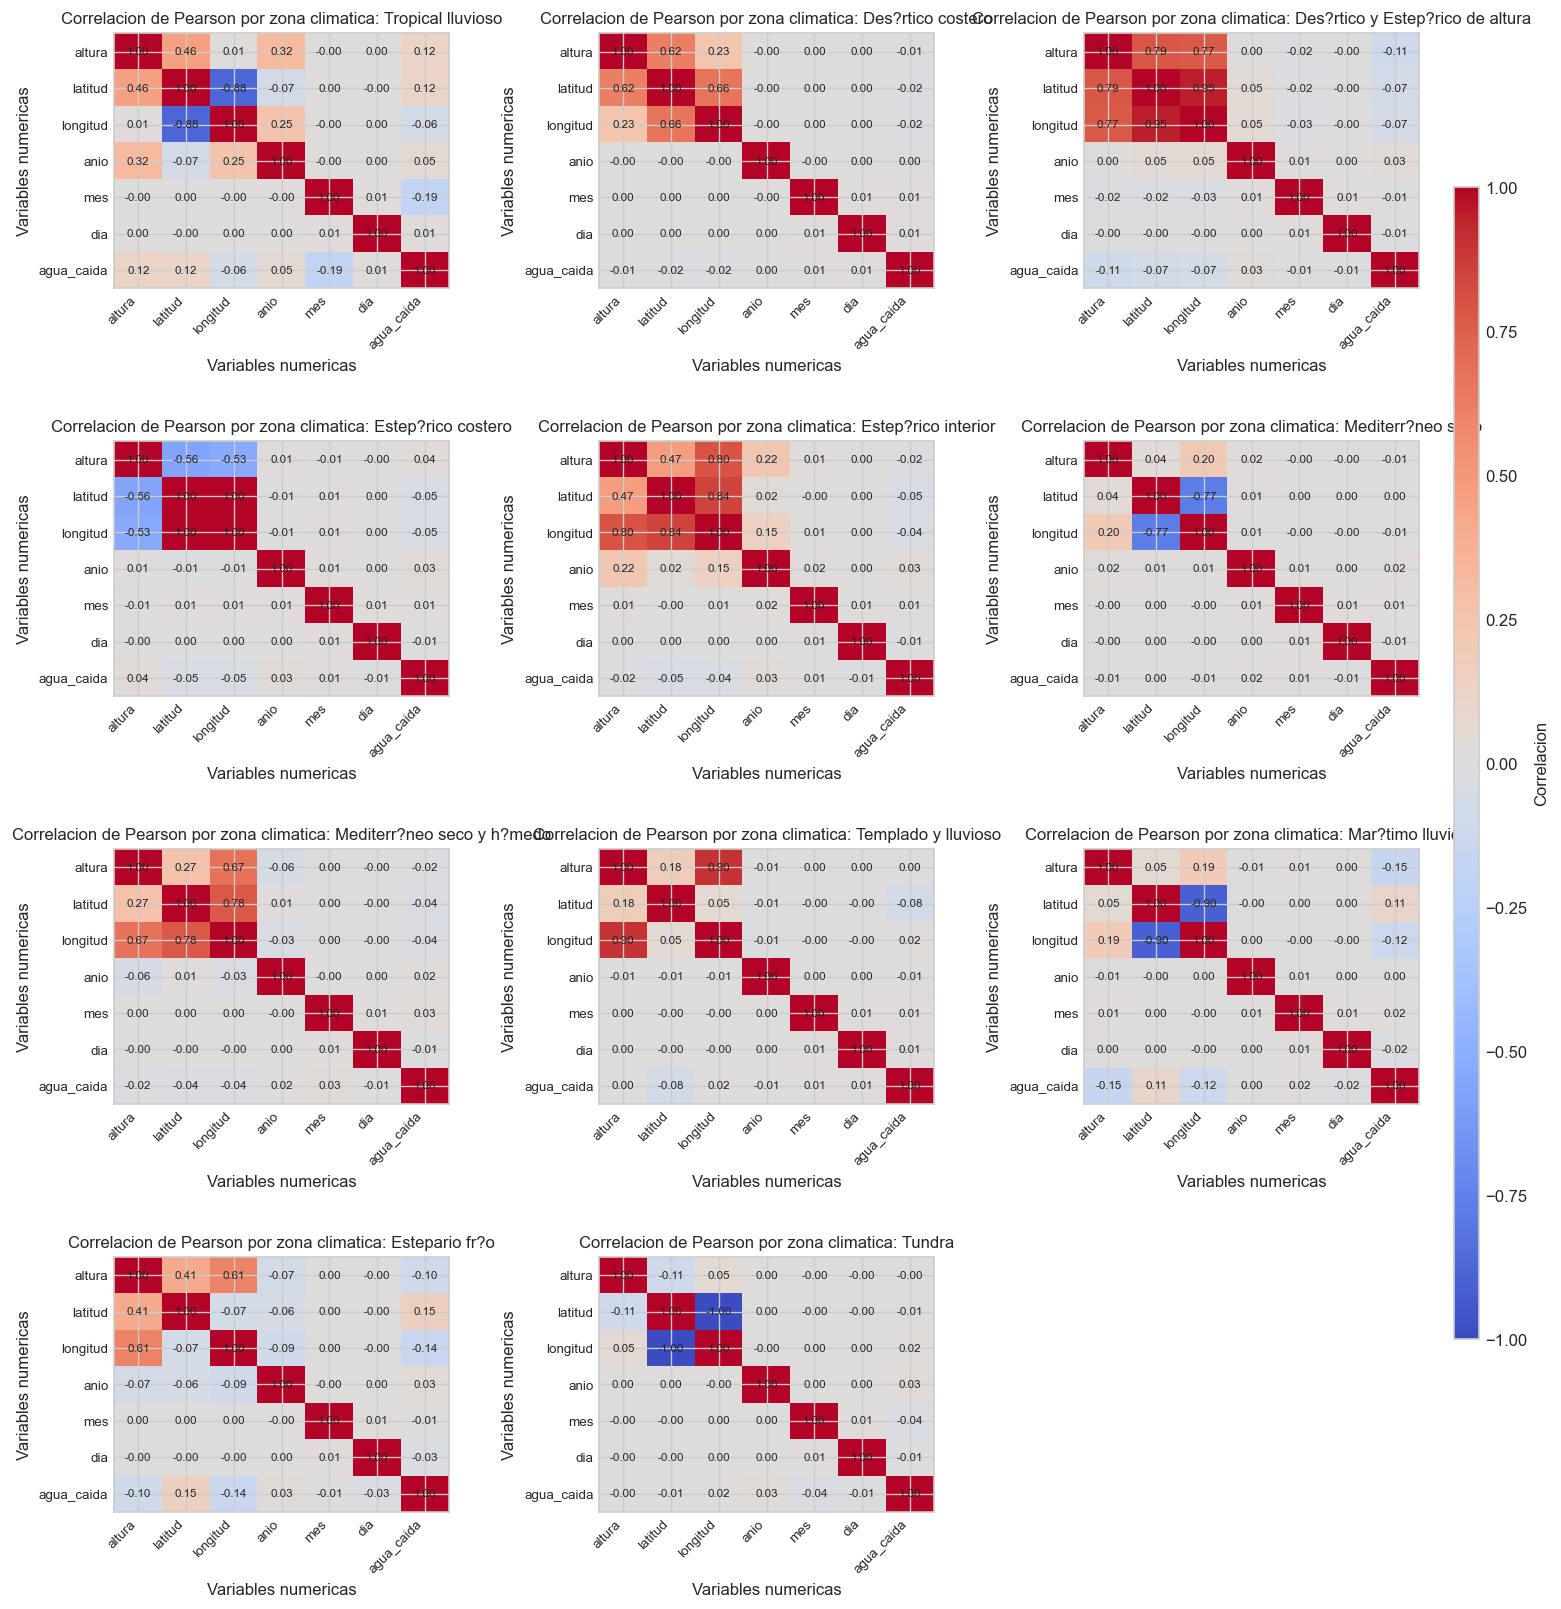

In [43]:
plot_group_heatmaps(
    corr_por_zona_climatica,
    "Correlacion de Pearson por zona climatica",
    ncols=3,
    base_figsize=(4.8, 4.0),
    xlabel="Variables numericas",
    ylabel="Variables numericas",
    cbar_label="Correlacion"
)


Finalmente, la segmentacion por `zona_climatica` permite ver si los regimenes hidrologicos agregados presentan estructuras distintas de correlacion. Esta lectura es especialmente util para conectar el analisis exploratorio con una clasificacion territorial mas interpretable para el informe.


**Analisis segmentado.** Estas matrices muestran que la correlacion no es completamente estable entre territorios. En algunas macrozonas la lluvia se relaciona mas con la latitud y la longitud, mientras que en otras gana peso la altura o la estacionalidad mensual. La lectura por `zona_geografica` y `zona_climatica` refuerza que no conviene defender una sola estructura lineal para todo el pais, porque el regimen pluviometrico cambia con bastante fuerza segun el contexto espacial.


Como complemento visual de las matrices de correlacion, se agregan tres graficos de dispersion globales. La idea no es reemplazar la lectura matricial, sino volver mas intuitivas algunas relaciones espaciales con `agua_caida_log`, usando colores para separar `zona_climatica`, `zona_geografica` y `macrozona`.


In [44]:
columnas_dispersion_global = [
    "latitud", "longitud", "altura", "agua_caida_log",
    "zona_climatica", "zona_geografica", "macrozona"
]

muestra_corr_visual = df_modelo[columnas_dispersion_global].dropna().copy()
if len(muestra_corr_visual) > 12000:
    muestra_corr_visual = muestra_corr_visual.sample(12000, random_state=42)

geo_palette = dict(
    zip(
        ACTIVE_GEO_ORDER,
        ["#0f766e", "#14b8a6", "#22c55e", "#84cc16", "#f59e0b", "#ef4444"][:len(ACTIVE_GEO_ORDER)],
    )
)

resumen_dispersion_global = pd.DataFrame(
    {
        "grafico": [
            "Latitud vs agua_caida_log por zona climatica",
            "Altura vs agua_caida_log por zona geografica",
            "Longitud vs agua_caida_log por macrozona",
        ],
        "correlacion_global": [
            round(df_modelo[["latitud", "agua_caida_log"]].corr().iloc[0, 1], 3),
            round(df_modelo[["altura", "agua_caida_log"]].corr().iloc[0, 1], 3),
            round(df_modelo[["longitud", "agua_caida_log"]].corr().iloc[0, 1], 3),
        ],
        "agrupacion_color": ["zona_climatica", "zona_geografica", "macrozona"],
        "muestra_usada": [len(muestra_corr_visual)] * 3,
    }
)

display(resumen_dispersion_global)


,grafico,correlacion_global,agrupacion_color,muestra_usada
0,Latitud vs agua_caida_log por zona climatica,-0.251,zona_climatica,12000
1,Altura vs agua_caida_log por zona geografica,-0.122,zona_geografica,12000
2,Longitud vs agua_caida_log por macrozona,-0.117,macrozona,12000


La tabla anterior deja explicito que estos dispersogramas no se eligieron al azar: cada panel usa una de las variables espaciales con mayor relacion global con `agua_caida_log`. Ademas, se trabaja con una muestra grande pero controlada para que la figura siga siendo legible y no se convierta en una nube opaca de puntos.


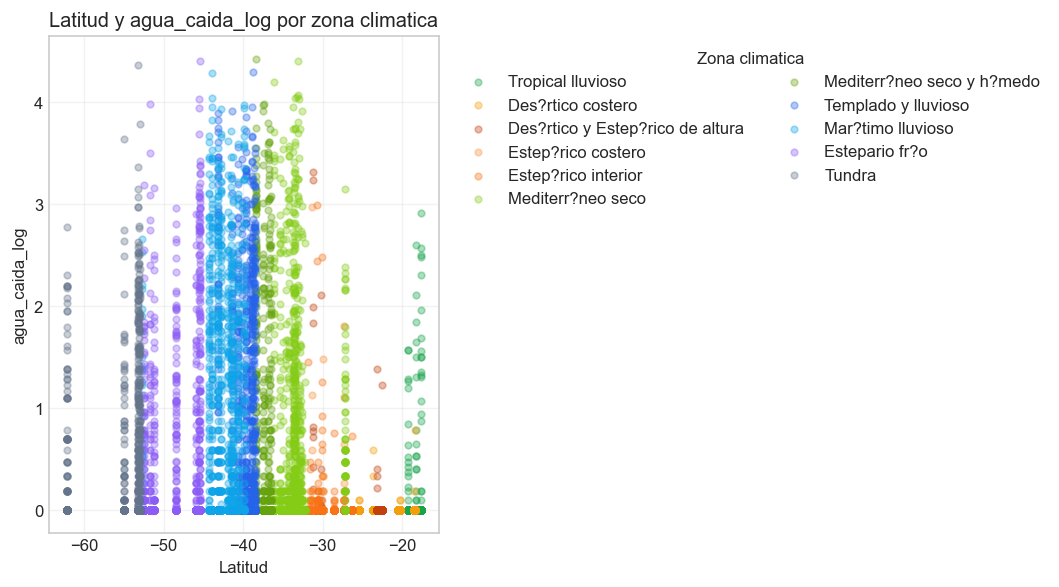

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

for zona in ACTIVE_CLIMATE_ORDER:
    subset = muestra_corr_visual.loc[muestra_corr_visual["zona_climatica"] == zona]
    if not subset.empty:
        ax.scatter(
            subset["latitud"],
            subset["agua_caida_log"],
            s=16,
            alpha=0.35,
            color=CLIMATE_COLORS.get(zona, "#94a3b8"),
            label=zona,
        )

ax.set_title("Latitud y agua_caida_log por zona climatica")
ax.set_xlabel("Latitud")
ax.set_ylabel("agua_caida_log")
ax.grid(alpha=0.25)
ax.legend(title="Zona climatica", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


El primer dispersograma usa `latitud` como eje horizontal y colorea por `zona_climatica`. Asi se puede ver si la gradiente norte-sur mantiene una forma similar dentro de cada regimen o si la dispersion cambia claramente entre climas.


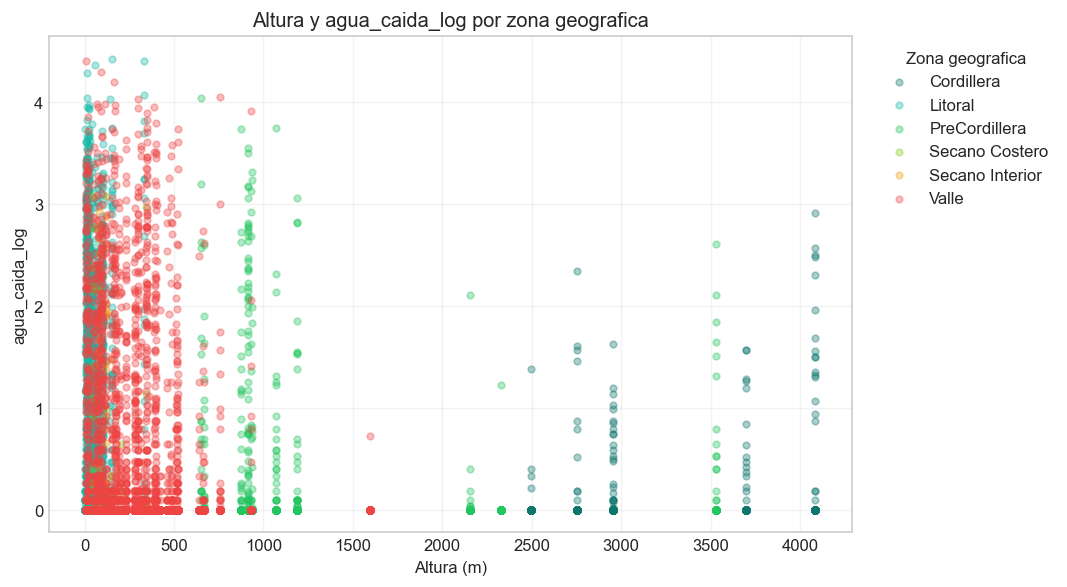

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))

for zona_geo in ACTIVE_GEO_ORDER:
    subset = muestra_corr_visual.loc[muestra_corr_visual["zona_geografica"] == zona_geo]
    if not subset.empty:
        ax.scatter(
            subset["altura"],
            subset["agua_caida_log"],
            s=16,
            alpha=0.35,
            color=geo_palette.get(zona_geo, "#94a3b8"),
            label=zona_geo,
        )

ax.set_title("Altura y agua_caida_log por zona geografica")
ax.set_xlabel("Altura (m)")
ax.set_ylabel("agua_caida_log")
ax.grid(alpha=0.25)
ax.legend(title="Zona geografica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


El segundo panel cambia el foco hacia `altura` y `zona_geografica`. Con esto se busca ver si el relieve se asocia de manera parecida con `agua_caida_log` en litoral, valle, cordillera y demas posiciones territoriales.


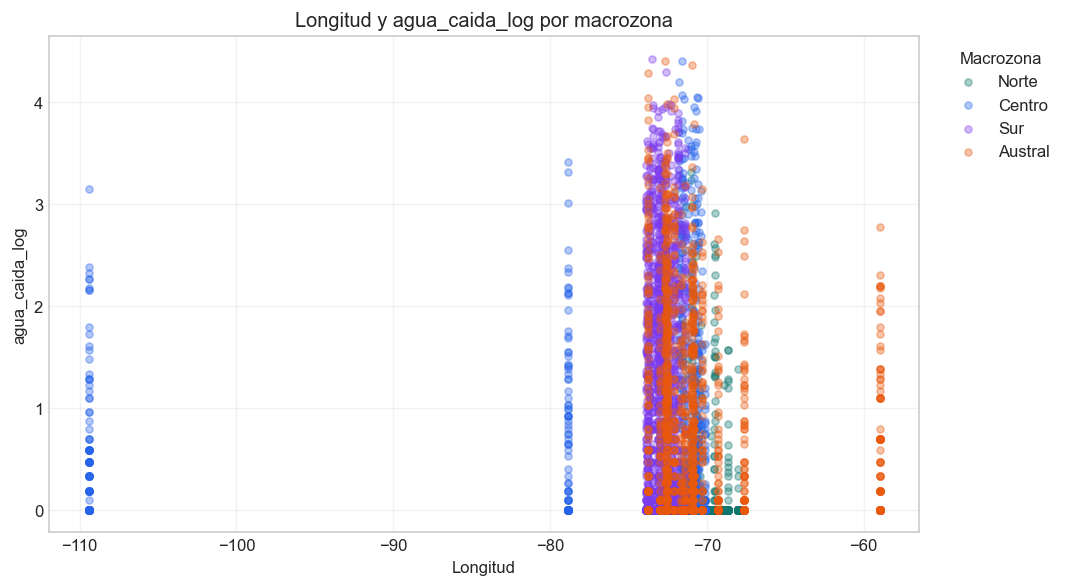

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))

for macrozona in [mz for mz in MACROZONE_ORDER if mz in muestra_corr_visual["macrozona"].unique()]:
    subset = muestra_corr_visual.loc[muestra_corr_visual["macrozona"] == macrozona]
    if not subset.empty:
        ax.scatter(
            subset["longitud"],
            subset["agua_caida_log"],
            s=18,
            alpha=0.35,
            color=MACROZONE_COLORS.get(macrozona, "#94a3b8"),
            label=macrozona,
        )

ax.set_title("Longitud y agua_caida_log por macrozona")
ax.set_xlabel("Longitud")
ax.set_ylabel("agua_caida_log")
ax.grid(alpha=0.25)
ax.legend(title="Macrozona", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


El tercer dispersograma toma `longitud` y colorea por `macrozona`, cerrando la lectura visual global con una agregacion territorial mas amplia. Juntos, los tres paneles traducen la correlacion a una forma menos abstracta y mas facil de explicar oralmente.


**Lectura visual global.** Estos tres dispersogramas complementan bien a las matrices porque traducen correlaciones debiles o moderadas en una forma mas intuitiva. El primer panel deja ver que la gradiente latitudinal no se distribuye igual entre zonas climaticas; el segundo muestra como la altura se combina con `zona_geografica`; y el tercero permite ver que la posicion longitudinal tampoco se reparte de forma identica entre macrozonas. En conjunto, la lectura refuerza que la precipitacion diaria no responde a un solo patron nacional, sino a una mezcla de estructura espacial, relieve y agrupacion territorial.


### 2.7 Patrones/comportamientos detectados


Mas alla de la correlacion lineal, el entendimiento de los datos exige observar patrones concretos en el tiempo y en el espacio. En esta subseccion se priorizan recuentos de registros y dias con lluvia, combinando tablas, barras y heatmaps para mostrar con mayor claridad como se distribuyen los eventos entre meses, anos, macrozonas, zonas climaticas y estaciones.


In [48]:
lluvia_mensual = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby("mes")
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        maxima_lluvia=("agua_caida", "max"),
    )
    .astype({"registros": int, "dias_con_lluvia": int})
)

display(lluvia_mensual)


,registros,dias_con_lluvia,maxima_lluvia
mes,,,
1,16027,2817,72.599998
2,14583,2713,66.000000
3,16027,3814,80.400002
4,15498,4788,136.399994
5,15996,5644,126.800003
6,15480,6485,145.199997
7,15996,6069,114.300003
8,15944,6032,150.199997
9,15420,4845,117.199997


El resumen mensual ahora se centra en cuantas observaciones existen y en cuantas de ellas hubo lluvia efectiva. Esto ayuda a separar disponibilidad de datos e intensidad maxima, en vez de resumir todo en una sola media.


In [49]:
lluvia_anual = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby("anio")
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        maxima_lluvia=("agua_caida", "max"),
    )
    .astype({"registros": int, "dias_con_lluvia": int})
)

display(lluvia_anual)


,registros,dias_con_lluvia,maxima_lluvia
anio,,,
2021,35606,9917,126.800003
2022,35735,10348,136.399994
2023,38325,10827,150.199997
2024,39162,10921,98.599998
2025,39048,10734,3574.300049


Aqui se observa la dimension temporal agregada con una logica mas concreta: cantidad de registros, cantidad de dias con lluvia y maximo diario observado. Asi se evita interpretar estacionalidad solo desde el promedio, que en precipitacion suele ocultar mucha dispersion.


In [50]:
recuento_clima_macro_mes = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby(["mes", "zona_climatica", "macrozona"])
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        estaciones=("nombre_estacion", "nunique"),
    )
    .reset_index()
)

display(recuento_clima_macro_mes.head(20))


,mes,zona_climatica,macrozona,registros,dias_con_lluvia,estaciones
0,1,Des?rtico costero,Norte,1240,8,8
1,1,Des?rtico y Estep?rico de altura,Norte,589,13,4
2,1,Estep?rico costero,Norte,465,9,3
3,1,Estep?rico interior,Norte,1085,1,8
4,1,Estepario fr?o,Austral,1023,424,7
5,1,Mar?timo lluvioso,Austral,434,253,3
6,1,Mar?timo lluvioso,Sur,1085,491,7
7,1,Mediterr?neo seco,Centro,5766,308,39
8,1,Mediterr?neo seco y h?medo,Sur,1116,114,8
9,1,Templado y lluvioso,Sur,1798,455,12


Despues se cruza la temporalidad con la clasificacion territorial. Este bloque deja listo el recuento de dias con lluvia por mes, `zona_climatica` y `macrozona`, para que el grafico muestre datos observados y no solo intensidades promedio.


In [51]:
top_estaciones = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby("nombre_estacion")
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        maxima_lluvia=("agua_caida", "max"),
        region=("nombre_region", "first"),
        zona_geografica=("zona_geografica", "first"),
        zona_climatica=("zona_climatica", "first"),
        macrozona=("macrozona", "first"),
    )
    .sort_values(["dias_con_lluvia", "registros"], ascending=False)
)

display(top_estaciones.head(12))


,registros,dias_con_lluvia,maxima_lluvia,region,zona_geografica,zona_climatica,macrozona
nombre_estacion,,,,,,,
Puerto Varas ESSAL,1826,1280,59.299999,De Los Lagos,Litoral,Mar?timo lluvioso,Sur
"Villa O""Higgins subcomisarÃ­a",1826,1256,94.199997,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Valle,Estepario fr?o,Austral
Melinka Ad.,1826,1234,120.000000,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Litoral,Mar?timo lluvioso,Austral
Nueva ChaitÃ©n,1826,1221,103.400002,De Los Lagos,Litoral,Mar?timo lluvioso,Sur
Puerto AysÃ©n Ad.,1826,1220,80.300003,AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,Valle,Estepario fr?o,Austral
Juan Kalt Bode (FundaciÃ³n Adolfo Matthei),1826,1214,50.400002,De Los Lagos,Valle,Templado y lluvioso,Sur
QuellÃ³n Ad.,1826,1167,72.199997,De Los Lagos,Litoral,Mar?timo lluvioso,Sur
Panguipulli,1821,1105,82.699997,De Los RÃ­os,Valle,Templado y lluvioso,Sur
Ancud Liceo AgrÃ­cola,1826,1100,49.700001,De Los Lagos,Litoral,Mar?timo lluvioso,Sur


Con este segundo bloque la mirada se desplaza hacia el territorio fino. En vez de ordenar las estaciones por promedio, se prioriza cuantas observaciones y cuantos dias con lluvia aporta cada una, lo que hace mas transparente la comparacion entre lugares con distinta cobertura temporal.


In [52]:
patron_clima_mes = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .pivot_table(
        index="mes",
        columns="zona_climatica",
        values="tiene_lluvia",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=ACTIVE_CLIMATE_ORDER, fill_value=0)
    .astype(int)
)

display(patron_clima_mes)


zona_climatica,Tropical lluvioso,Des?rtico costero,Des?rtico y Estep?rico de altura,Estep?rico costero,Estep?rico interior,Mediterr?neo seco,Mediterr?neo seco y h?medo,Templado y lluvioso,Mar?timo lluvioso,Estepario fr?o,Tundra
mes,,,,,,,,,,,
1,192,8,13,9,1,308,114,455,744,424,549
2,185,11,15,13,3,331,110,435,695,406,509
3,189,1,14,11,22,453,255,781,930,568,590
4,41,6,21,18,53,950,482,1123,1030,544,520
5,3,5,36,24,80,1535,573,1225,1079,591,493
6,2,6,53,72,155,2135,666,1284,1052,593,467
7,0,9,49,66,192,1571,622,1310,1096,645,509
8,22,8,50,71,173,1859,569,1150,1036,604,490
9,21,10,16,34,41,1245,474,1047,997,549,411


La tabla mensual por `zona_climatica` deja cuantificados los dias con lluvia, pero todavia en formato resumido. El siguiente bloque convierte esa informacion en un panel temporal mas legible: un grafico mensual general y una desagregacion por `macrozona`.


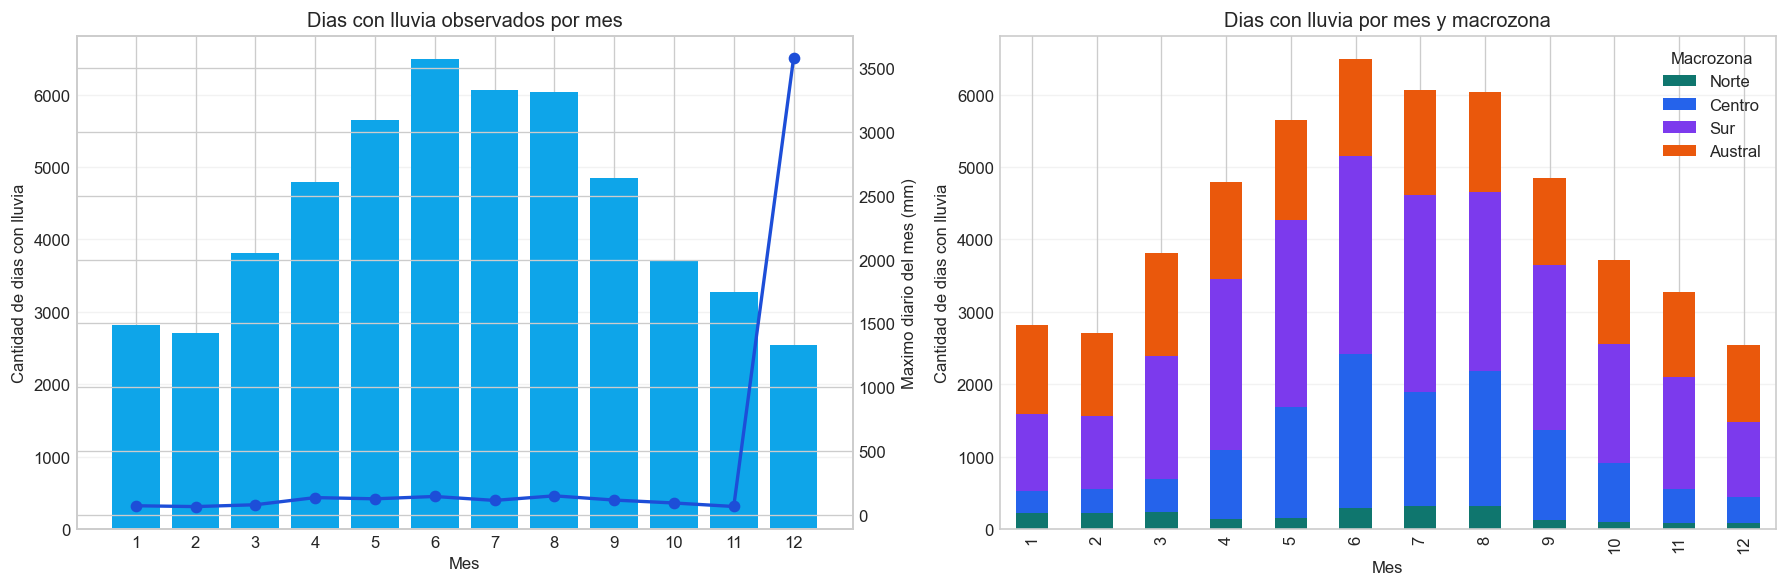

In [53]:
mensual_macrozona = (
    recuento_clima_macro_mes.groupby(["mes", "macrozona"])["dias_con_lluvia"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=[mz for mz in MACROZONE_ORDER if mz in recuento_clima_macro_mes["macrozona"].unique()], fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(lluvia_mensual.index, lluvia_mensual["dias_con_lluvia"], color="#0ea5e9")
axes[0].set_title("Dias con lluvia observados por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Cantidad de dias con lluvia")
axes[0].set_xticks(range(1, 13))
axes[0].grid(axis="y", alpha=0.25)

ax0b = axes[0].twinx()
ax0b.plot(
    lluvia_mensual.index,
    lluvia_mensual["maxima_lluvia"],
    color="#1d4ed8",
    marker="o",
    linewidth=2,
)
ax0b.set_ylabel("Maximo diario del mes (mm)")

mensual_macrozona.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[MACROZONE_COLORS.get(col, "#94a3b8") for col in mensual_macrozona.columns],
)
axes[1].set_title("Dias con lluvia por mes y macrozona")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Cantidad de dias con lluvia")
axes[1].legend(title="Macrozona")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


Las visualizaciones temporales se simplifican para que la lectura sea mas directa. El primer panel muestra la estacionalidad mensual de los dias con lluvia y la complementa con el maximo diario del mes. El segundo panel reparte esos dias entre macrozonas, de modo que se vea de inmediato en que tramo del pais se concentra el aporte mensual del fenomeno.

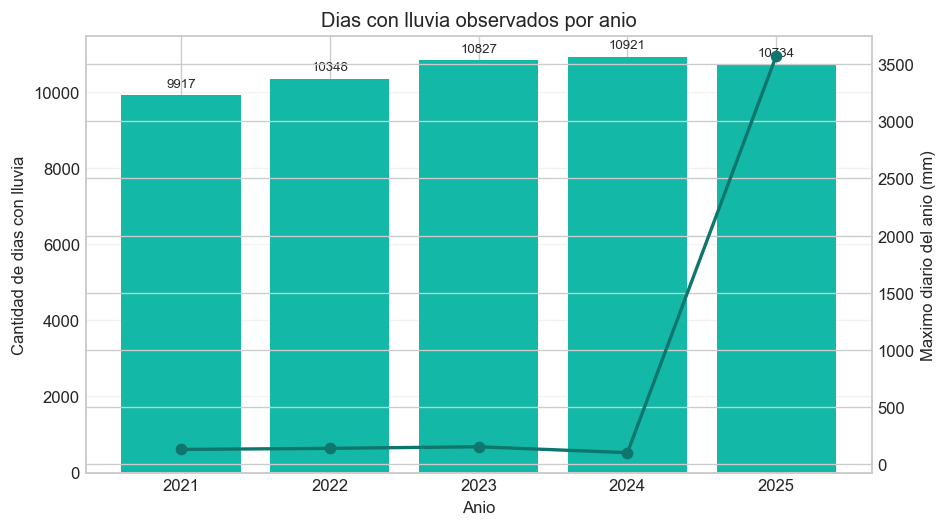

In [54]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(lluvia_anual.index.astype(str), lluvia_anual["dias_con_lluvia"], color="#14b8a6")
ax.set_title("Dias con lluvia observados por anio")
ax.set_xlabel("Anio")
ax.set_ylabel("Cantidad de dias con lluvia")
ax.grid(axis="y", alpha=0.25)

for anio, valor in lluvia_anual["dias_con_lluvia"].items():
    ax.text(str(anio), valor + lluvia_anual["dias_con_lluvia"].max() * 0.02, int(valor), ha="center", fontsize=8)

ax2 = ax.twinx()
ax2.plot(
    lluvia_anual.index.astype(str),
    lluvia_anual["maxima_lluvia"],
    color="#0f766e",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Maximo diario del anio (mm)")

plt.tight_layout()
plt.show()


El resumen anual complementa la lectura mensual y sirve para verificar si hay anos con mas eventos o con maximos diarios especialmente altos. Despues de esa vista agregada, el heatmap vuelve a la distribucion por `zona_climatica` y mes.


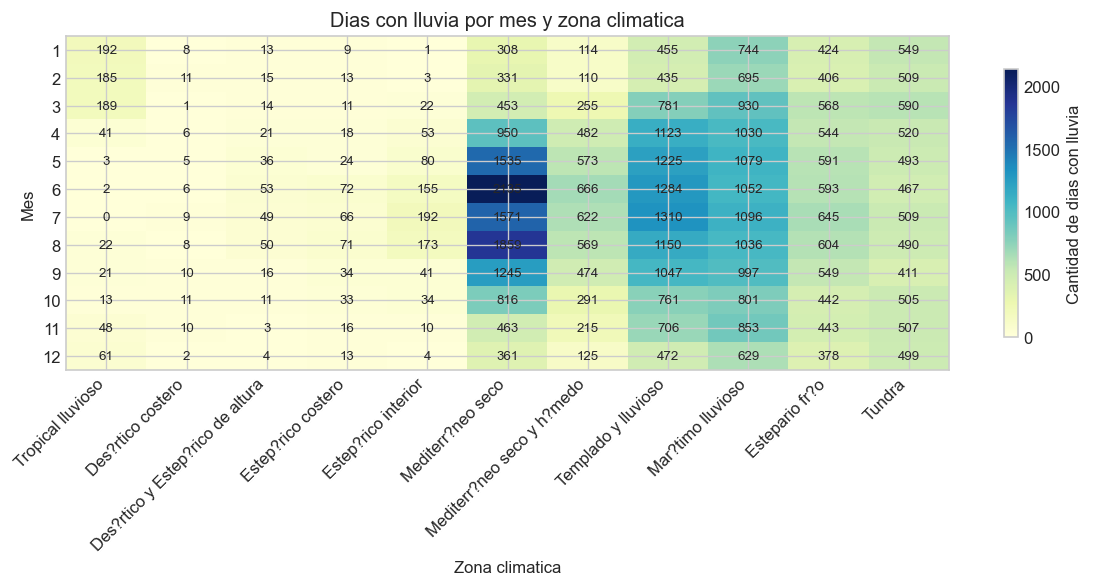

In [55]:
heatmap_df(
    patron_clima_mes,
    "Dias con lluvia por mes y zona climatica",
    cmap="YlGnBu",
    figsize=(10, 5),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Mes",
    cbar_label="Cantidad de dias con lluvia",
)


In [56]:
df_graficos_geo_clima = (
    df_modelo.assign(tiene_lluvia=(df_modelo["agua_caida"] > 0).astype(int))
    .groupby(["zona_geografica", "zona_climatica", "macrozona"], observed=False)
    .agg(
        estaciones=("nombre_estacion", "nunique"),
        registros=("agua_caida", "size"),
        dias_con_lluvia=("tiene_lluvia", "sum"),
        frecuencia_lluvia_pct=("tiene_lluvia", lambda s: round(s.mean() * 100, 1)),
        mediana_agua_caida=("agua_caida", "median"),
    )
    .reset_index()
    .sort_values(["dias_con_lluvia", "registros"], ascending=False)
)

perfil_geo_clima = df_graficos_geo_clima.copy()
display(perfil_geo_clima)


,zona_geografica,zona_climatica,macrozona,estaciones,registros,dias_con_lluvia,frecuencia_lluvia_pct,mediana_agua_caida
21,Valle,Templado y lluvioso,Sur,11,19351,9873,51.0,0.078025
5,Litoral,Mar?timo lluvioso,Sur,7,12782,7889,61.7,0.302566
18,Valle,Estepario fr?o,Austral,7,12052,6187,51.3,0.100000
8,Litoral,Tundra,Austral,7,12773,6049,47.4,0.000000
19,Valle,Mediterr?neo seco,Centro,21,35237,5402,15.3,0.000000
6,Litoral,Mediterr?neo seco,Centro,8,14608,3799,26.0,0.000000
4,Litoral,Mar?timo lluvioso,Austral,3,4959,3053,61.6,0.400000
20,Valle,Mediterr?neo seco y h?medo,Sur,4,7304,2126,29.1,0.000000
7,Litoral,Mediterr?neo seco y h?medo,Sur,3,5112,2065,40.4,0.000000
10,PreCordillera,Mediterr?neo seco,Centro,6,10296,1595,15.5,0.000000


Este cruce territorial funciona como una lectura de cobertura y ocurrencia. Para graficarlo sin confundir combinaciones inexistentes con valores reales iguales a cero, se construye un dataframe especifico de visualizacion llamado `df_graficos_geo_clima`. Desde esa tabla resumen se levantan los heatmaps, dejando en blanco las combinaciones `zona_geografica` x `zona_climatica` que no aparecen en la base.

In [57]:
conteo_estaciones_geo_clima = df_graficos_geo_clima.copy()

estaciones_geo_clima = (
    conteo_estaciones_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="estaciones",
        aggfunc="sum",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

precipitacion_geo_clima = (
    conteo_estaciones_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="dias_con_lluvia",
        aggfunc="sum",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

display(estaciones_geo_clima)
display(precipitacion_geo_clima)


zona_climatica,Tropical lluvioso,Des?rtico costero,Des?rtico y Estep?rico de altura,Estep?rico costero,Estep?rico interior,Mediterr?neo seco,Mediterr?neo seco y h?medo,Templado y lluvioso,Mar?timo lluvioso,Estepario fr?o,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,2.0,NaN,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,8.0,NaN,NaN,NaN,8.0,3.0,NaN,10.0,NaN,7.0
PreCordillera,1.0,NaN,3.0,NaN,NaN,6.0,NaN,1.0,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,3.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,8.0,21.0,4.0,11.0,NaN,7.0,NaN


zona_climatica,Tropical lluvioso,Des?rtico costero,Des?rtico y Estep?rico de altura,Estep?rico costero,Estep?rico interior,Mediterr?neo seco,Mediterr?neo seco y h?medo,Templado y lluvioso,Mar?timo lluvioso,Estepario fr?o,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,531.0,NaN,56.0,NaN,NaN,515.0,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,87.0,NaN,NaN,NaN,3799.0,2065.0,NaN,10942.0,NaN,6049.0
PreCordillera,246.0,NaN,229.0,NaN,NaN,1595.0,NaN,876.0,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,380.0,NaN,279.0,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,437.0,305.0,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,768.0,5402.0,2126.0,9873.0,NaN,6187.0,NaN


Con `df_graficos_geo_clima` ya construido, primero se levantan dos matrices de cobertura: cantidad de estaciones y cantidad de dias con lluvia. Esto permite separar de manera ordenada el respaldo territorial del volumen de eventos antes de pasar a frecuencia e intensidad tipica.


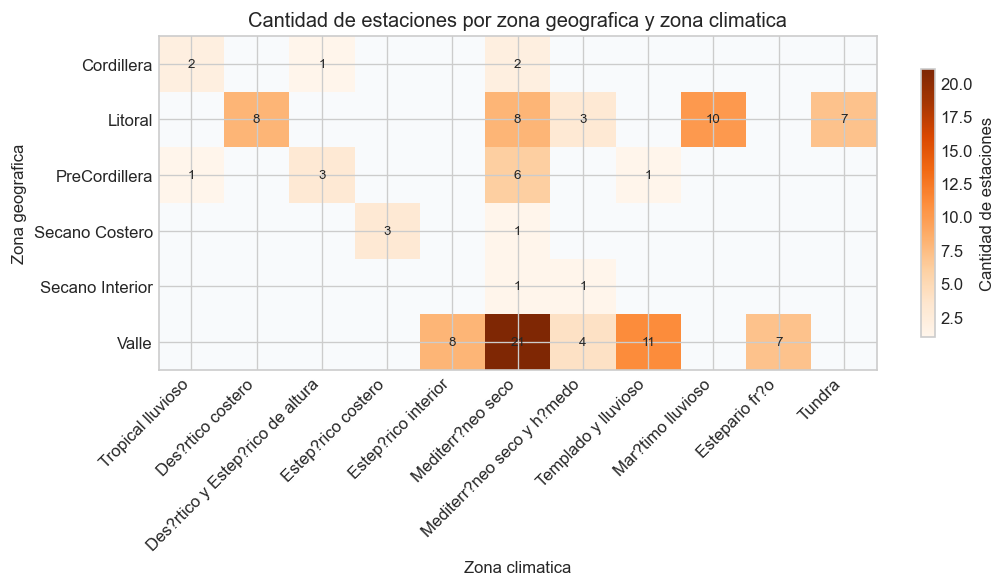

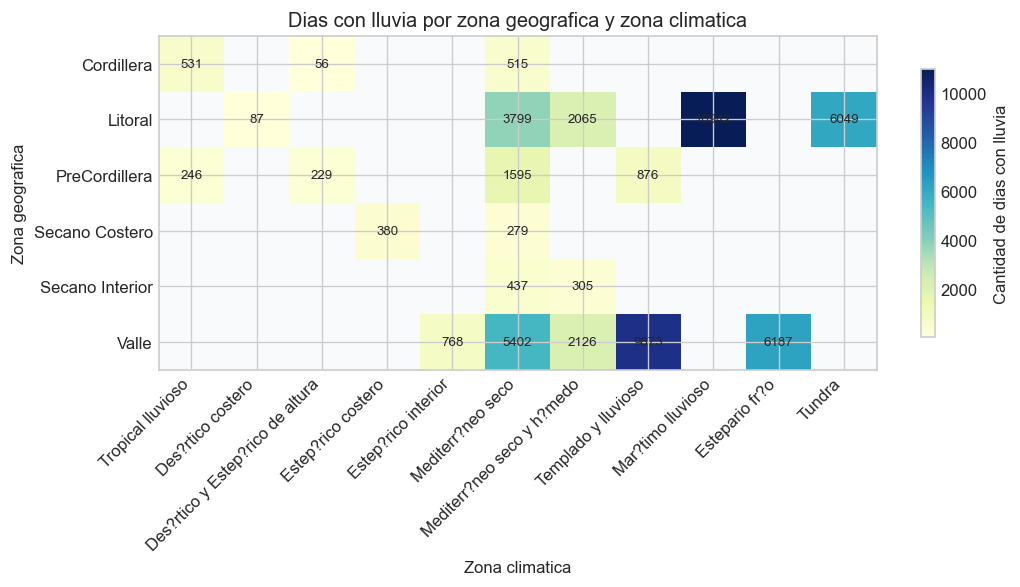

In [58]:
heatmap_df(
    estaciones_geo_clima,
    "Cantidad de estaciones por zona geografica y zona climatica",
    cmap="Oranges",
    figsize=(9, 5),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Cantidad de estaciones",
)

heatmap_df(
    precipitacion_geo_clima,
    "Dias con lluvia por zona geografica y zona climatica",
    cmap="YlGnBu",
    figsize=(9, 5),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Cantidad de dias con lluvia",
)


El conteo de dias con lluvia muestra cobertura, pero no separa intensidad tipica de probabilidad relativa. Para complementar esa lectura, se reutiliza `df_graficos_geo_clima` y se construyen matrices de frecuencia y mediana. En estos graficos, las celdas vacias representan combinaciones territoriales no observadas en la base, no faltantes pendientes de imputacion.

In [59]:
frecuencia_geo_clima_pct = (
    df_graficos_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="frecuencia_lluvia_pct",
        aggfunc="mean",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

mediana_geo_clima = (
    df_graficos_geo_clima.pivot_table(
        index="zona_geografica",
        columns="zona_climatica",
        values="mediana_agua_caida",
        aggfunc="mean",
    )
    .reindex(index=ACTIVE_GEO_ORDER, columns=ACTIVE_CLIMATE_ORDER)
)

display(frecuencia_geo_clima_pct)
display(mediana_geo_clima)


zona_climatica,Tropical lluvioso,Des?rtico costero,Des?rtico y Estep?rico de altura,Estep?rico costero,Estep?rico interior,Mediterr?neo seco,Mediterr?neo seco y h?medo,Templado y lluvioso,Mar?timo lluvioso,Estepario fr?o,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,24.2,NaN,3.3,NaN,NaN,14.1,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,0.6,NaN,NaN,NaN,26.0,40.4,NaN,61.65,NaN,47.4
PreCordillera,13.5,NaN,4.5,NaN,NaN,15.5,NaN,48.0,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,7.0,NaN,15.3,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,23.9,41.7,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,6.1,15.3,29.1,51.0,NaN,51.3,NaN


zona_climatica,Tropical lluvioso,Des?rtico costero,Des?rtico y Estep?rico de altura,Estep?rico costero,Estep?rico interior,Mediterr?neo seco,Mediterr?neo seco y h?medo,Templado y lluvioso,Mar?timo lluvioso,Estepario fr?o,Tundra
zona_geografica,,,,,,,,,,,
Cordillera,0.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
Litoral,NaN,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.351283,NaN,0.0
PreCordillera,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.000000,NaN,NaN,NaN
Secano Costero,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
Secano Interior,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
Valle,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.078025,NaN,0.1,NaN


A partir de la misma base de visualizacion, ahora se calculan dos medidas mas interpretativas: la frecuencia de lluvia y la mediana de `agua_caida`. Los heatmaps siguientes muestran esas dos dimensiones por separado para no confundir ocurrencia con intensidad central.


Estas tablas ayudan a separar dos dimensiones que suelen confundirse: una combinacion territorial puede acumular muchos eventos por volumen de registros, pero no necesariamente tener una frecuencia alta; del mismo modo, una mediana baja puede convivir con algunos extremos intensos. Ademas, las celdas en blanco muestran de forma explicita que ciertas combinaciones no existen en el dataset, evitando interpretarlas como ceros reales.

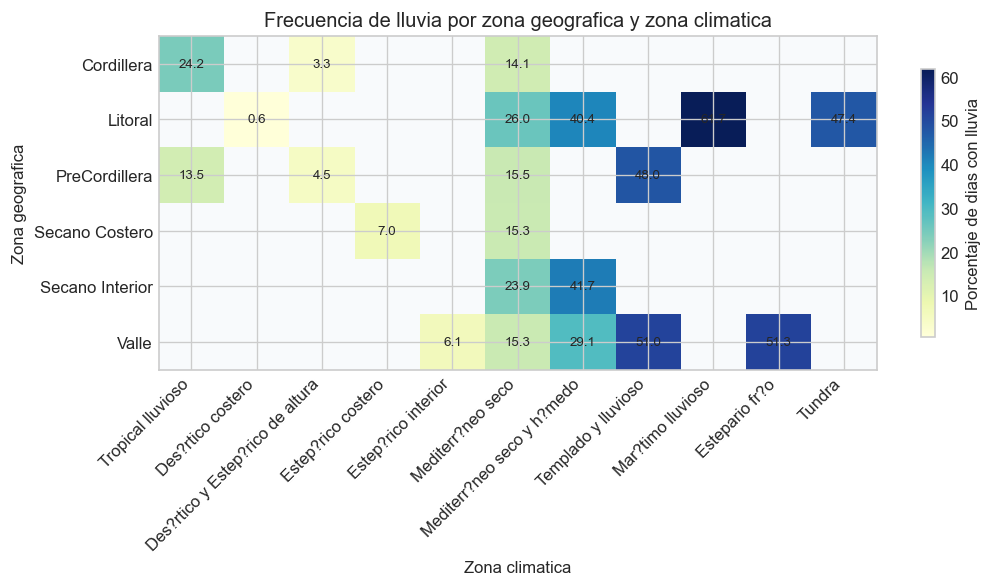

In [60]:
heatmap_df(
    frecuencia_geo_clima_pct,
    "Frecuencia de lluvia por zona geografica y zona climatica",
    cmap="YlGnBu",
    figsize=(9, 5),
    decimals=1,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Porcentaje de dias con lluvia"
)


El primer heatmap de este bloque muestra la frecuencia relativa de lluvia. A continuacion, la mediana complementa esa lectura y permite distinguir si una combinacion territorial tiende a registrar lluvias tipicas mas altas o solo mas frecuentes.


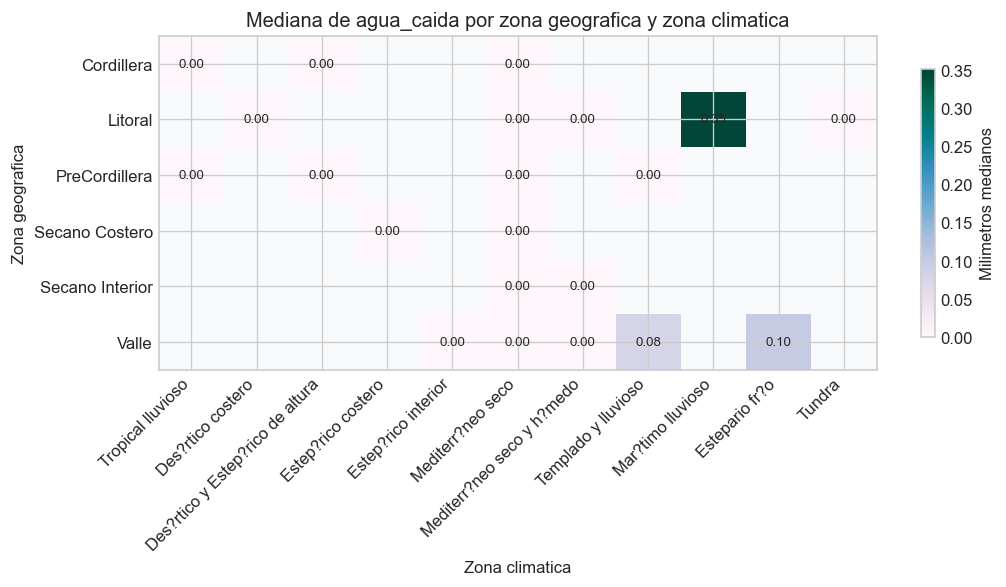

In [61]:
heatmap_df(
    mediana_geo_clima,
    "Mediana de agua_caida por zona geografica y zona climatica",
    cmap="PuBuGn",
    figsize=(9, 5),
    decimals=2,
    xlabel="Zona climatica",
    ylabel="Zona geografica",
    cbar_label="Milimetros medianos"
)


**Analisis.** El patron espacial se entiende mejor cuando se mira como recuento y no solo como promedio. La dispersion territorial deja ver donde se concentran realmente las observaciones con lluvia y que combinaciones de `zona_geografica`, `zona_climatica` y `macrozona` tienen mayor respaldo empirico. El heatmap de dias con lluvia muestra el volumen de eventos acumulados, mientras que los heatmaps de frecuencia y mediana separan mejor la probabilidad de ocurrencia y la intensidad central del fenomeno. Que algunas celdas queden en blanco es metodologicamente correcto: no indican nulos sin tratar, sino cruces territoriales no observados en la muestra disponible.

### 2.8 Nuevas variables a partir del analisis


A partir de los patrones detectados, resulta conveniente construir variables que representen mejor la naturaleza ciclica del tiempo y la agrupacion territorial de las estaciones. La finalidad de estas nuevas variables no es aumentar artificialmente la dimensionalidad, sino incorporar estructuras que las columnas originales no capturan de forma directa.


In [62]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

estaciones = {
    12: "Verano", 1: "Verano", 2: "Verano",
    3: "Otono", 4: "Otono", 5: "Otono",
    6: "Invierno", 7: "Invierno", 8: "Invierno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}

df_features = df_modelo.copy()
df_features["estacion_anual"] = df_features["mes"].map(estaciones)
df_features["estacion_anual"] = pd.Categorical(
    df_features["estacion_anual"],
    categories=orden_estaciones,
    ordered=True,
)
df_features["dia_del_anio"] = df_features["fecha"].dt.dayofyear

display(df_features[["fecha", "mes", "estacion_anual", "dia_del_anio"]].head(12))


,fecha,mes,estacion_anual,dia_del_anio
0,2023-01-01,1,Verano,1
1,2023-01-02,1,Verano,2
2,2023-01-03,1,Verano,3
3,2023-01-04,1,Verano,4
4,2023-01-05,1,Verano,5
5,2023-01-06,1,Verano,6
6,2023-01-07,1,Verano,7
7,2023-01-08,1,Verano,8
8,2023-01-09,1,Verano,9
9,2023-01-10,1,Verano,10


El primer grupo de variables derivadas resume la posicion del registro dentro del calendario. Esto permite pasar de un tiempo crudo a una representacion mas interpretativa y cercana a la logica meteorologica.


In [63]:
df_features["mes_sin"] = np.sin(2 * np.pi * df_features["mes"] / 12)
df_features["mes_cos"] = np.cos(2 * np.pi * df_features["mes"] / 12)
df_features["dia_sin"] = np.sin(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["dia_cos"] = np.cos(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["lluvia_evento"] = (df_features["agua_caida"] > 0).astype(int)

display(
    df_features[
        [
            "fecha", "mes_sin", "mes_cos", "dia_sin", "dia_cos",
            "zona_climatica", "macrozona", "lluvia_evento"
        ]
    ].head(12)
)


,fecha,mes_sin,mes_cos,dia_sin,dia_cos,zona_climatica,macrozona,lluvia_evento
0,2023-01-01,0.5,0.866025,0.017202,0.999852,Tropical lluvioso,Norte,1
1,2023-01-02,0.5,0.866025,0.034398,0.999408,Tropical lluvioso,Norte,1
2,2023-01-03,0.5,0.866025,0.051584,0.998669,Tropical lluvioso,Norte,1
3,2023-01-04,0.5,0.866025,0.068755,0.997634,Tropical lluvioso,Norte,1
4,2023-01-05,0.5,0.866025,0.085906,0.996303,Tropical lluvioso,Norte,1
5,2023-01-06,0.5,0.866025,0.103031,0.994678,Tropical lluvioso,Norte,1
6,2023-01-07,0.5,0.866025,0.120126,0.992759,Tropical lluvioso,Norte,1
7,2023-01-08,0.5,0.866025,0.137185,0.990545,Tropical lluvioso,Norte,1
8,2023-01-09,0.5,0.866025,0.154204,0.988039,Tropical lluvioso,Norte,1
9,2023-01-10,0.5,0.866025,0.171177,0.985240,Tropical lluvioso,Norte,1


**Analisis.** Las variables derivadas permiten representar de mejor manera la dinamica observada en la fase exploratoria. `estacion_anual` resume el calendario meteorologico, las componentes ciclicas evitan tratar el tiempo como una escala lineal simple y las clasificaciones territoriales `zona_climatica` y `macrozona` ayudan a sintetizar diferencias espaciales de mayor escala sin perder interpretabilidad.


### 2.9 Matriz de Correlacion


Con las nuevas variables disponibles, se recalcula la matriz de correlacion utilizando `agua_caida_log` como referencia analitica. Esta decision permite reducir el efecto de la asimetria extrema de la variable objetivo y facilita una lectura mas interpretable de las asociaciones lineales entre la precipitacion y las variables derivadas. Igual que en la subseccion anterior, la lectura no se deja solo a nivel global: tambien se calcula una matriz por `zona_geografica`, para verificar si las nuevas variables explican de forma distinta el fenomeno segun el contexto territorial.


In [64]:
corr_extendida = df_features[
    [
        "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos",
        "dia_sin", "dia_cos", "agua_caida_log"
    ]
].copy()

for zona in ACTIVE_CLIMATE_ORDER:
    nombre_columna = zona.lower().replace(" ", "_")
    corr_extendida[f"clima_{nombre_columna}"] = (df_features["zona_climatica"] == zona).astype(int)

for zona_geo in ACTIVE_GEO_ORDER:
    nombre_geo = zona_geo.lower().replace(" ", "_")
    corr_extendida[f"geo_{nombre_geo}"] = (df_features["zona_geografica"] == zona_geo).astype(int)

display(corr_extendida.head())


,altura,latitud,longitud,anio,mes_sin,mes_cos,dia_sin,dia_cos,agua_caida_log,clima_tropical_lluvioso,clima_des?rtico_costero,clima_des?rtico_y_estep?rico_de_altura,clima_estep?rico_costero,clima_estep?rico_interior,clima_mediterr?neo_seco,clima_mediterr?neo_seco_y_h?medo,clima_templado_y_lluvioso,clima_mar?timo_lluvioso,clima_estepario_fr?o,clima_tundra,geo_cordillera,geo_litoral,geo_precordillera,geo_secano_costero,geo_secano_interior,geo_valle
0,4084,-17.595,-69.4775,2023,0.5,0.866025,0.017202,0.999852,1.255757,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,4084,-17.595,-69.4775,2023,0.5,0.866025,0.034398,0.999408,1.123814,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,4084,-17.595,-69.4775,2023,0.5,0.866025,0.051584,0.998669,0.729876,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,4084,-17.595,-69.4775,2023,0.5,0.866025,0.068755,0.997634,0.788889,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,4084,-17.595,-69.4775,2023,0.5,0.866025,0.085906,0.996303,0.817804,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


Antes de calcular la correlacion conviene revisar explicitamente la matriz de trabajo. Asi se observa que la correlacion extendida ya no se limita a columnas originales: incorpora variables ciclicas, codificacion binaria de las zonas climaticas y tambien dummies de `zona_geografica`, porque en esta etapa interesa capturar mejor la estructura territorial del problema.


In [65]:
matriz_corr_extendida = corr_extendida.corr(numeric_only=True).round(3)

columnas_corr_extendida_por_zona = [
    "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos",
    "dia_sin", "dia_cos", "agua_caida_log"
] + [
    col for col in corr_extendida.columns if col.startswith("clima_")
]

corr_extendida_geo = corr_extendida.copy()
corr_extendida_geo["zona_geografica"] = df_features["zona_geografica"].values

corr_extendida_por_zona = build_group_corr_dict(
    corr_extendida_geo,
    "zona_geografica",
    columnas_corr_extendida_por_zona,
    group_order=ACTIVE_GEO_ORDER,
    min_rows=100,
    drop_constant=True,
)

variables_resumen_extendido = [
    "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos", "dia_sin", "dia_cos"
]

resumen_corr_extendida_zona = pd.DataFrame(
    {
        zona: matriz["agua_caida_log"].reindex(variables_resumen_extendido)
        for zona, matriz in corr_extendida_por_zona.items()
    }
).T.round(3)

resumen_corr_extendida_zona.index.name = "zona_geografica"

display(matriz_corr_extendida)
display(matriz_corr_extendida["agua_caida_log"].sort_values(ascending=False))
display(resumen_corr_extendida_zona)


,altura,latitud,longitud,anio,mes_sin,mes_cos,dia_sin,dia_cos,agua_caida_log,clima_tropical_lluvioso,clima_des?rtico_costero,clima_des?rtico_y_estep?rico_de_altura,clima_estep?rico_costero,clima_estep?rico_interior,clima_mediterr?neo_seco,clima_mediterr?neo_seco_y_h?medo,clima_templado_y_lluvioso,clima_mar?timo_lluvioso,clima_estepario_fr?o,clima_tundra,geo_cordillera,geo_litoral,geo_precordillera,geo_secano_costero,geo_secano_interior,geo_valle
altura,1.000,0.393,0.182,0.043,0.002,-0.001,0.002,-0.000,-0.122,0.655,-0.152,0.396,-0.049,0.019,0.089,-0.110,-0.098,-0.172,-0.083,-0.148,0.726,-0.376,0.430,-0.070,-0.056,-0.148
latitud,0.393,1.000,-0.062,0.013,0.001,-0.001,0.001,-0.001,-0.251,0.292,0.485,0.201,0.124,0.186,0.206,-0.046,-0.158,-0.267,-0.374,-0.575,0.213,-0.149,0.181,0.124,0.009,-0.102
longitud,0.182,-0.062,1.000,0.006,0.001,-0.001,0.001,-0.000,-0.117,0.085,0.095,0.095,0.023,0.058,-0.103,-0.064,-0.070,-0.094,-0.034,0.197,0.113,-0.141,0.100,0.022,-0.005,0.023
anio,0.043,0.013,0.006,1.000,-0.002,0.004,-0.004,0.003,0.005,0.052,-0.011,-0.012,-0.005,0.015,-0.010,0.016,-0.001,-0.010,0.007,-0.010,0.037,-0.021,-0.006,-0.007,0.031,0.004
mes_sin,0.002,0.001,0.001,-0.002,1.000,-0.001,0.954,0.260,-0.056,-0.000,-0.001,0.003,-0.000,0.000,0.000,-0.001,-0.001,0.002,-0.001,-0.001,0.003,-0.000,0.001,-0.001,-0.000,-0.001
mes_cos,-0.001,-0.001,-0.001,0.004,-0.001,1.000,-0.259,0.954,-0.161,0.001,0.001,-0.002,-0.001,-0.002,-0.000,0.001,0.001,-0.000,0.001,0.001,-0.002,0.001,0.001,-0.000,0.000,-0.001
dia_sin,0.002,0.001,0.001,-0.004,0.954,-0.259,1.000,0.002,-0.011,-0.000,-0.001,0.004,-0.000,0.001,0.000,-0.001,-0.001,0.002,-0.001,-0.001,0.003,-0.001,0.001,-0.000,-0.000,-0.001
dia_cos,-0.000,-0.001,-0.000,0.003,0.260,0.954,0.002,1.000,-0.173,0.000,0.001,-0.001,-0.001,-0.002,-0.000,0.001,0.001,0.000,0.001,0.000,-0.001,0.001,0.001,-0.001,0.000,-0.001
agua_caida_log,-0.122,-0.251,-0.117,0.005,-0.056,-0.161,-0.011,-0.173,1.000,-0.028,-0.127,-0.076,-0.067,-0.103,-0.154,0.049,0.156,0.233,0.094,0.037,-0.057,0.099,-0.068,-0.071,-0.012,-0.000
clima_tropical_lluvioso,0.655,0.292,0.085,0.052,-0.000,0.001,-0.000,0.000,-0.028,1.000,-0.043,-0.029,-0.026,-0.040,-0.111,-0.041,-0.053,-0.048,-0.039,-0.040,0.381,-0.107,0.173,-0.030,-0.017,-0.137


agua_caida_log                            1.000
clima_mar?timo_lluvioso                   0.233
clima_templado_y_lluvioso                 0.156
geo_litoral                               0.099
clima_estepario_fr?o                      0.094
clima_mediterr?neo_seco_y_h?medo          0.049
clima_tundra                              0.037
anio                                      0.005
geo_valle                                -0.000
dia_sin                                  -0.011
geo_secano_interior                      -0.012
clima_tropical_lluvioso                  -0.028
mes_sin                                  -0.056
geo_cordillera                           -0.057
clima_estep?rico_costero                 -0.067
geo_precordillera                        -0.068
geo_secano_costero                       -0.071
clima_des?rtico_y_estep?rico_de_altura   -0.076
clima_estep?rico_interior                -0.103
longitud                                 -0.117
altura                                  

,altura,latitud,longitud,anio,mes_sin,mes_cos,dia_sin,dia_cos
zona_geografica,,,,,,,,
Cordillera,0.215,0.107,-0.061,0.028,0.084,0.071,0.061,0.091
Litoral,-0.093,-0.235,-0.098,0.002,-0.037,-0.142,0.001,-0.148
PreCordillera,-0.089,-0.148,-0.142,0.025,-0.057,-0.155,-0.015,-0.172
Secano Costero,-0.068,-0.122,-0.110,0.020,-0.075,-0.153,-0.033,-0.171
Secano Interior,0.146,-0.146,-0.146,0.023,-0.042,-0.274,0.031,-0.285
Valle,-0.191,-0.269,-0.318,0.008,-0.078,-0.193,-0.025,-0.212


La celda anterior arma la matriz extendida y, ademas, recalcula la correlacion por `zona_geografica` descartando columnas constantes dentro de cada grupo. Ese detalle metodologico es importante porque evita llenar los heatmaps segmentados con `NaN` artificiales provocados por dummies sin variacion.


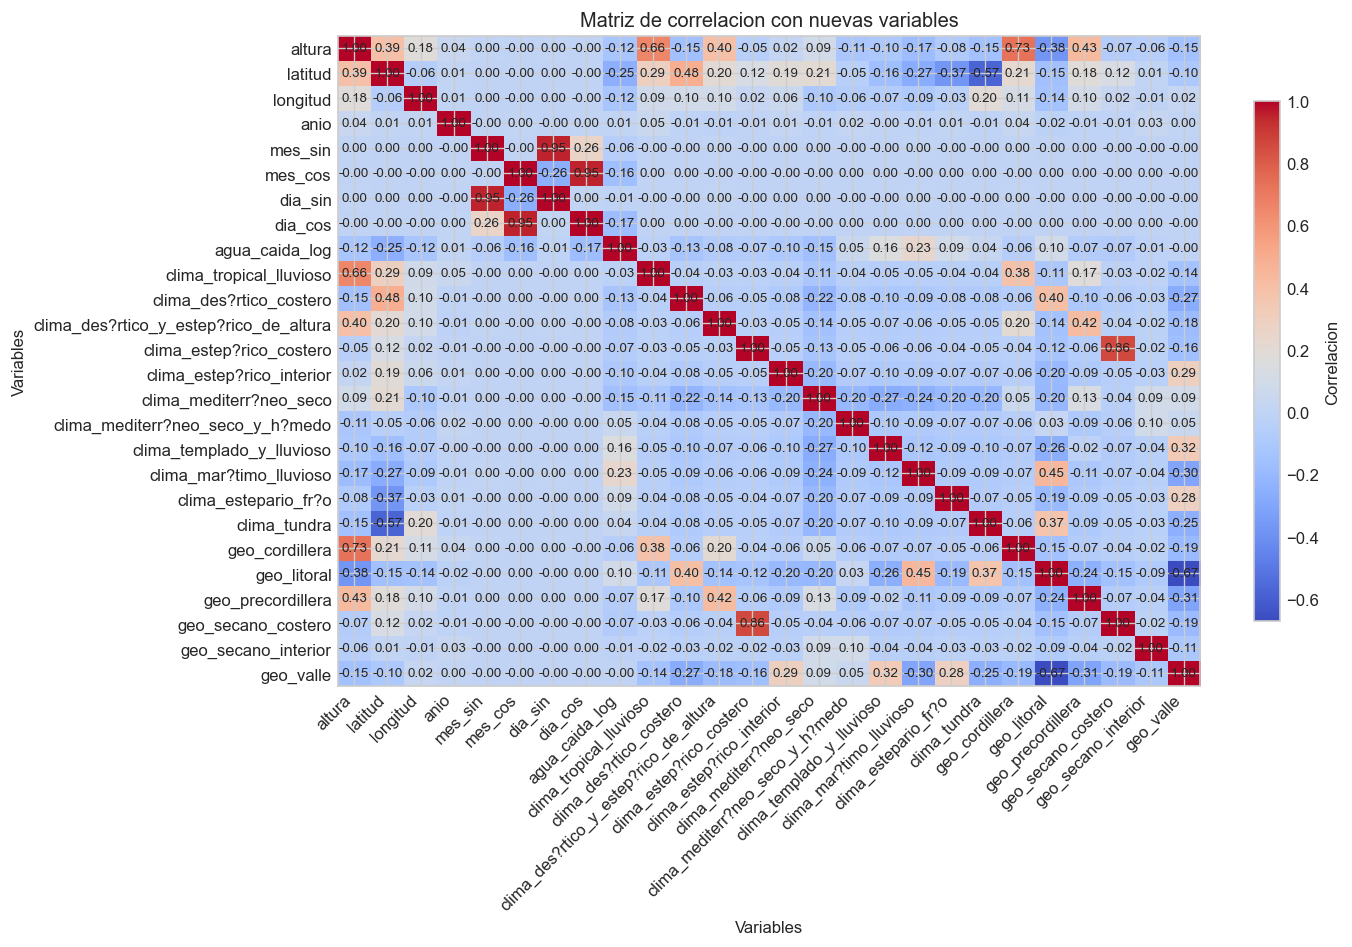

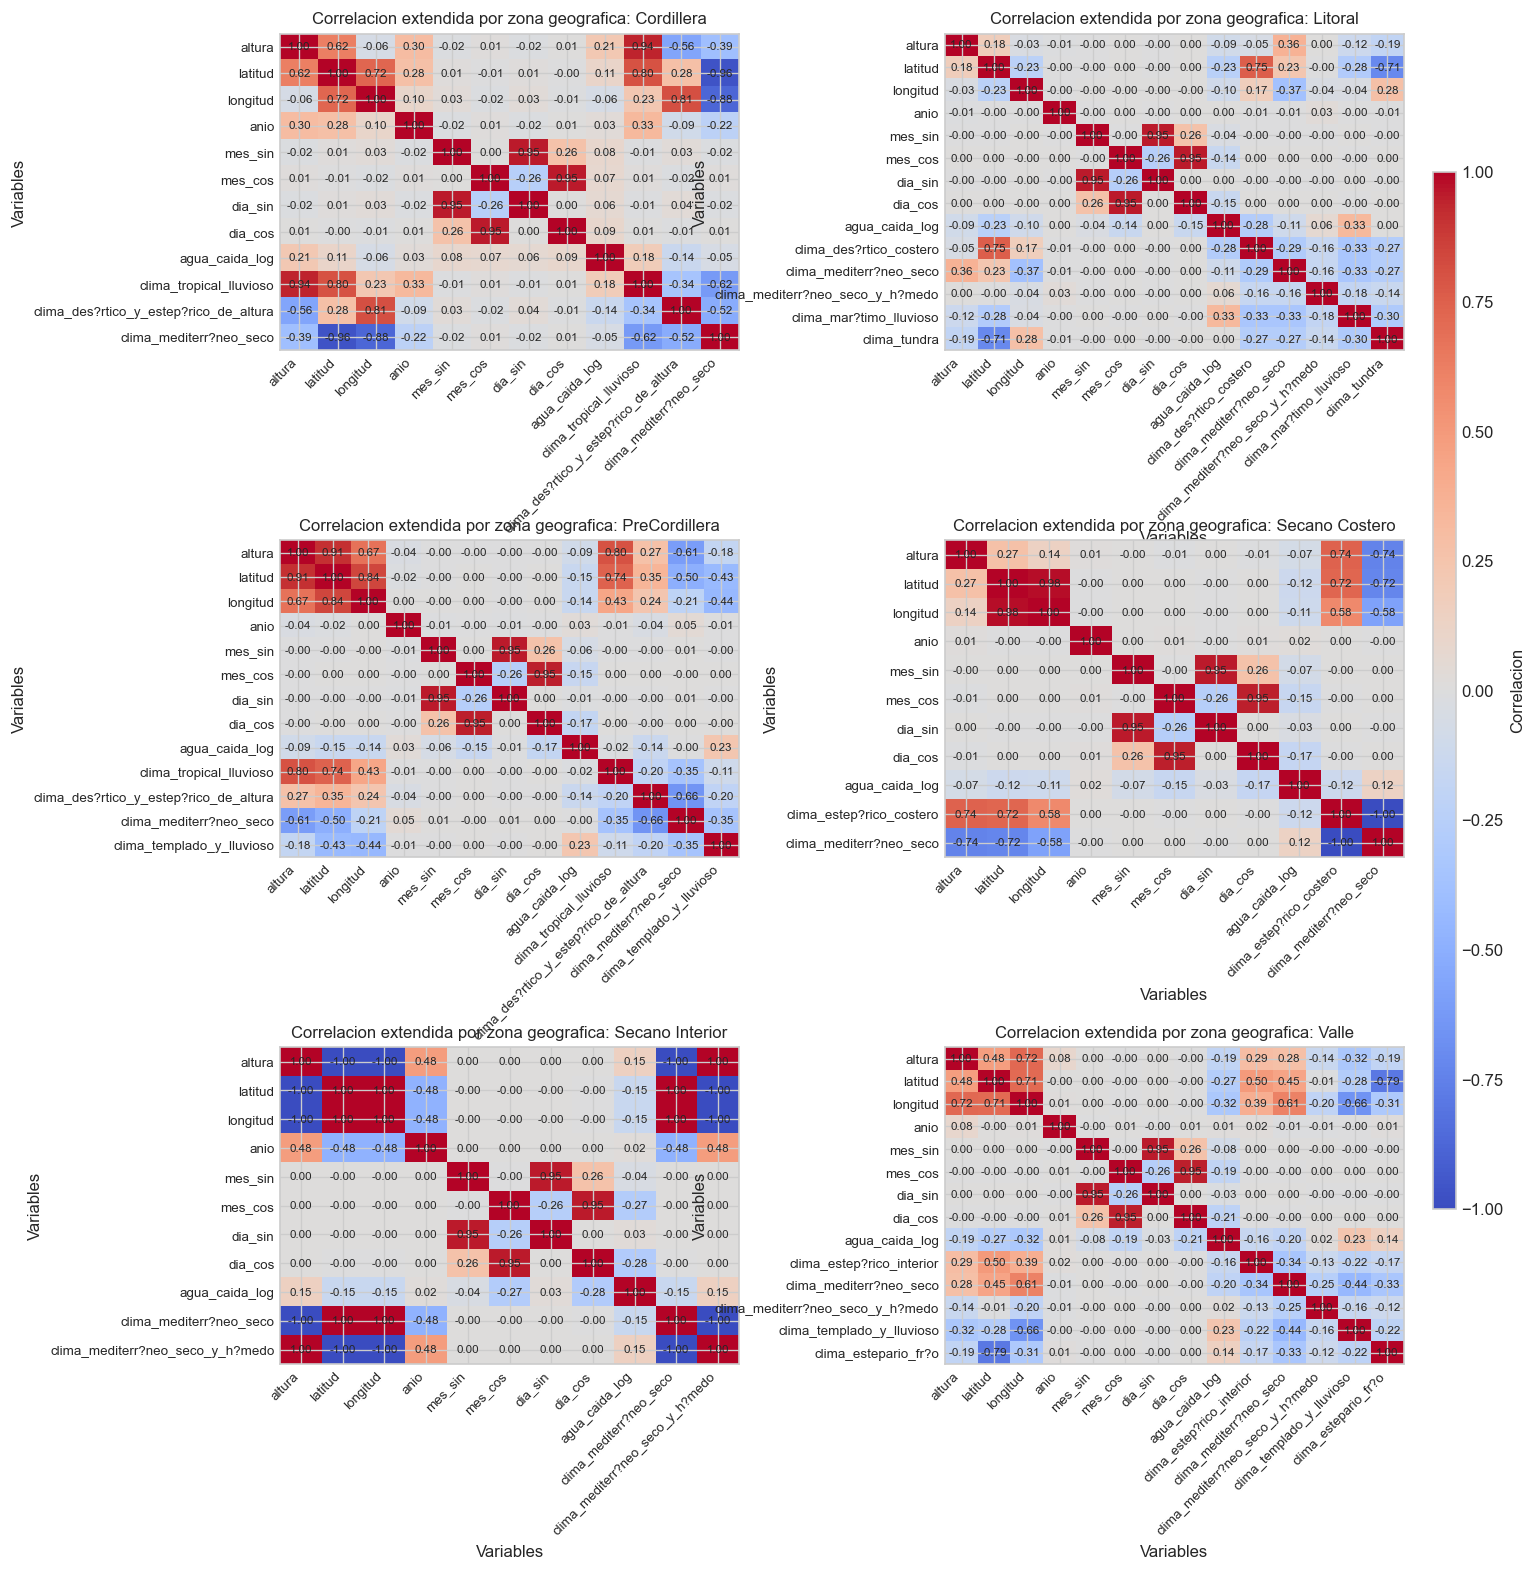

In [66]:
heatmap_df(
    matriz_corr_extendida,
    "Matriz de correlacion con nuevas variables",
    cmap="coolwarm",
    figsize=(12, 8),
    decimals=2,
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)

plot_group_heatmaps(
    corr_extendida_por_zona,
    "Correlacion extendida por zona geografica",
    cmap="coolwarm",
    decimals=2,
    ncols=2,
    base_figsize=(6.2, 4.8),
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)


**Analisis.** La nueva matriz resulta bastante mas interpretable que la inicial porque incorpora estructuras temporales y una clasificacion territorial explicita. A nivel global ya se nota mejor el aporte de las componentes ciclicas, la latitud y las dummies climaticas, pero la lectura por `zona_geografica` vuelve a ser clave: no todas las zonas responden igual a las mismas variables derivadas. En algunas, la estacionalidad pesa mas; en otras, la posicion espacial o la pertenencia climatica gana protagonismo. Esto refuerza una idea importante para defender el notebook: las nuevas variables no solo agregan columnas, sino que permiten describir mejor un fenomeno cuyo comportamiento cambia segun el contexto geografico.


### 2.10 Patrones/comportamientos detectados con nuevas variables


Finalmente, se revisa si las variables creadas ayudan a revelar patrones mas claros en la precipitacion diaria. En particular, interesa observar como cambia el comportamiento entre zonas climaticas y estaciones del ano, sin perder de vista que cada grupo sigue conteniendo estaciones, zonas geograficas y regiones distintas en su interior.


In [67]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

recuento_estacional = (
    df_features.groupby(["estacion_anual", "zona_climatica", "macrozona"], observed=False)
    .agg(
        registros=("agua_caida", "size"),
        dias_con_lluvia=("lluvia_evento", "sum"),
    )
    .reset_index()
)

recuento_estacional["estacion_anual"] = pd.Categorical(
    recuento_estacional["estacion_anual"],
    categories=orden_estaciones,
    ordered=True,
)
recuento_estacional = recuento_estacional.sort_values(["estacion_anual", "zona_climatica", "macrozona"])

display(
    recuento_estacional.sort_values(["dias_con_lluvia", "registros"], ascending=False).head(20)
)


,estacion_anual,zona_climatica,macrozona,registros,dias_con_lluvia
113,Invierno,Mediterr?neo seco,Centro,17020,5565
123,Invierno,Templado y lluvioso,Sur,5336,3744
79,Otono,Templado y lluvioso,Sur,5336,3129
69,Otono,Mediterr?neo seco,Centro,17069,2938
157,Primavera,Mediterr?neo seco,Centro,16755,2524
167,Primavera,Templado y lluvioso,Sur,5278,2514
111,Invierno,Mar?timo lluvioso,Sur,3220,2331
67,Otono,Mar?timo lluvioso,Sur,3220,2195
155,Primavera,Mar?timo lluvioso,Sur,3185,1978
119,Invierno,Mediterr?neo seco y h?medo,Sur,3312,1857


Una vez creadas las variables derivadas, conviene volver a mirar la estacionalidad, pero ahora como numero de eventos observados. Este enfoque es mas consistente con la naturaleza intermitente de la lluvia diaria y permite ver mejor la combinacion entre estacion del ano, `zona_climatica` y `macrozona`.


In [68]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

frecuencia_zona_climatica = (
    df_features.pivot_table(
        index="estacion_anual",
        columns="zona_climatica",
        values="lluvia_evento",
        aggfunc="sum",
        fill_value=0,
        observed=False,
    )
    .reindex(orden_estaciones)
    .reindex(columns=ACTIVE_CLIMATE_ORDER, fill_value=0)
    .astype(int)
)

frecuencia_zona_climatica.index.name = "estacion_anual"

display(frecuencia_zona_climatica)


zona_climatica,Tropical lluvioso,Des?rtico costero,Des?rtico y Estep?rico de altura,Estep?rico costero,Estep?rico interior,Mediterr?neo seco,Mediterr?neo seco y h?medo,Templado y lluvioso,Mar?timo lluvioso,Estepario fr?o,Tundra
estacion_anual,,,,,,,,,,,
Verano,438,21,32,35,8,1000,349,1362,2068,1208,1557
Otono,233,12,71,53,155,2938,1310,3129,3039,1703,1603
Invierno,24,23,152,209,520,5565,1857,3744,3184,1842,1466
Primavera,82,31,30,83,85,2524,980,2514,2651,1434,1423


La tabla complementaria resume los dias con lluvia por estacion del ano y zona climatica. Asi se conserva una vista compacta para comparar clases, pero sin volver al promedio como unica medida descriptiva.


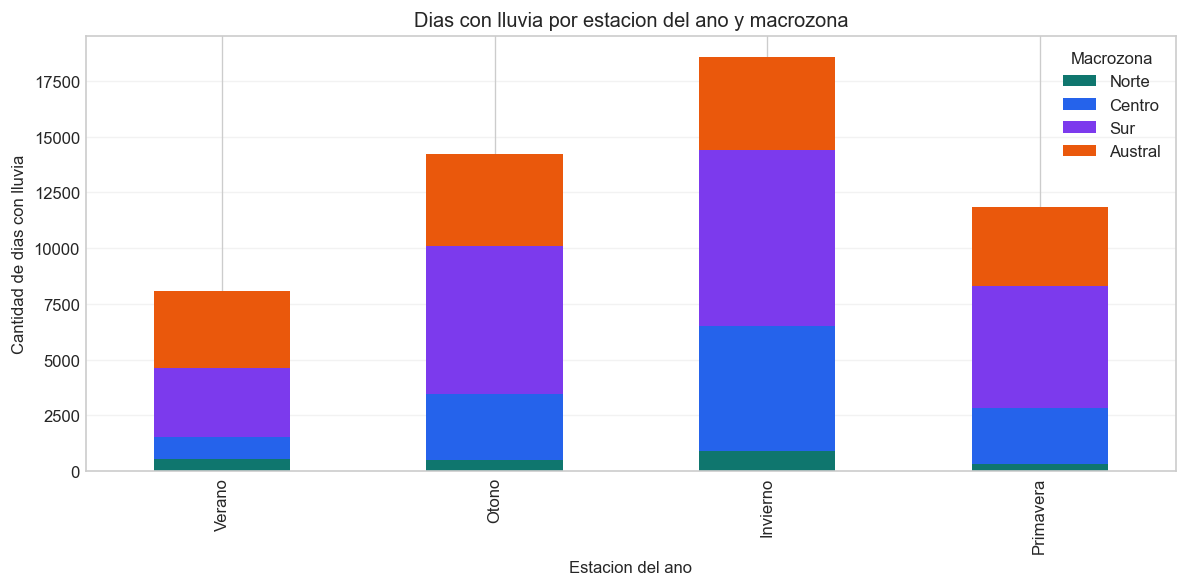

In [69]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

estacional_macrozona = (
    recuento_estacional.groupby(["estacion_anual", "macrozona"], observed=False)["dias_con_lluvia"]
    .sum()
    .unstack(fill_value=0)
    .reindex(index=orden_estaciones, columns=[mz for mz in MACROZONE_ORDER if mz in recuento_estacional["macrozona"].unique()], fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
estacional_macrozona.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[MACROZONE_COLORS.get(col, "#94a3b8") for col in estacional_macrozona.columns],
)
ax.set_title("Dias con lluvia por estacion del ano y macrozona")
ax.set_xlabel("Estacion del ano")
ax.set_ylabel("Cantidad de dias con lluvia")
ax.legend(title="Macrozona")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


La barra apilada por `macrozona` resume la distribucion estacional de los eventos de lluvia a gran escala. El heatmap siguiente completa la lectura mostrando la misma idea desde la perspectiva de `zona_climatica`.


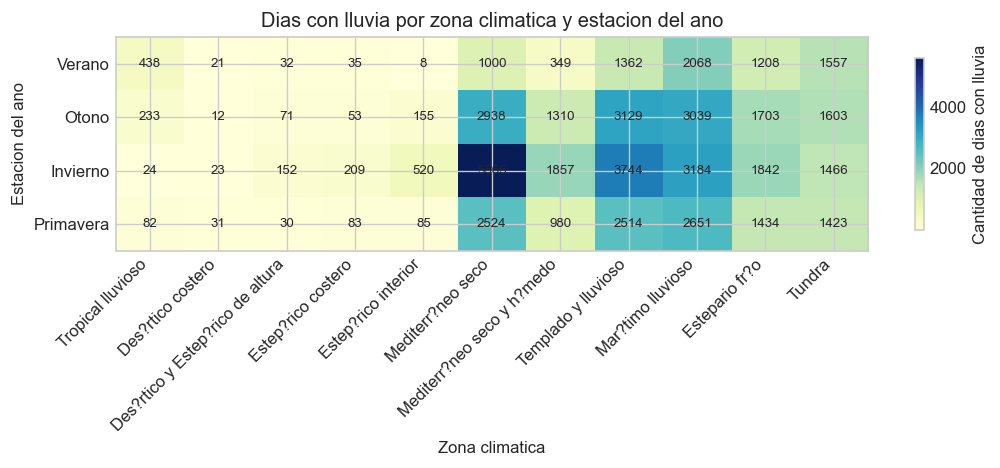

In [70]:
heatmap_df(
    frecuencia_zona_climatica,
    "Dias con lluvia por zona climatica y estacion del ano",
    cmap="YlGnBu",
    figsize=(9, 4),
    decimals=0,
    xlabel="Zona climatica",
    ylabel="Estacion del ano",
    cbar_label="Cantidad de dias con lluvia",
)


**Analisis.** Con las nuevas variables, la estacionalidad se vuelve mucho mas facil de defender porque ya no depende solo de un promedio por clase. El grafico de barras apiladas muestra cuantos eventos de lluvia aparecen realmente en cada estacion del ano y como esos eventos se reparten entre macrozonas, mientras que el heatmap permite comparar rapidamente la contribucion de cada `zona_climatica`. En conjunto, ambas vistas refuerzan que los regimenes lluviosos del sur y austral concentran mas dias con precipitacion, mientras que los sectores aridos y mediterraneos secos presentan una ocurrencia mucho mas acotada y estacional.


## 3. Transformacion

En esta fase se consolidan las transformaciones necesarias para dejar la base en una forma apta para etapas posteriores de modelamiento. El foco ya no esta en descubrir patrones nuevos, sino en traducir lo aprendido en la fase 2 a una representacion numerica, trazable y metodologicamente consistente.

### 3.1 Escalamiento

El escalamiento se concentra en las variables continuas, pero se implementa junto con tres resguardos metodologicos. Primero, se preserva la trazabilidad de los registros imputados para no tratar estimaciones como observaciones reales. Segundo, el `StandardScaler` se ajusta solo sobre un bloque temporal de referencia, reduciendo el riesgo de fuga de informacion. Tercero, las variables categoricas derivadas se codifican sin redundancia perfecta, dejando una matriz mas estable para las tecnicas de modelamiento posteriores.


In [71]:
resumen_objetivo_modelado = pd.DataFrame(
    {
        "filas_totales_en_df_features": [len(df_features)],
        "filas_con_target_observado": [int((df_features["agua_caida_imputada"] == 0).sum())],
        "filas_con_target_imputado": [int((df_features["agua_caida_imputada"] == 1).sum())],
    }
)

display(resumen_objetivo_modelado)


,filas_totales_en_df_features,filas_con_target_observado,filas_con_target_imputado
0,187876,170813,17063


**Depuracion del subconjunto supervisado.** Antes de escalar, se identifica el subconjunto que puede utilizarse como base supervisada sin ambiguedad. Los registros con `agua_caida_imputada = 1` siguen siendo utiles para analisis descriptivo, pero no conviene tratarlos como valores observados al preparar entrenamiento y evaluacion.


In [72]:
corte_temporal = pd.Timestamp("2025-01-01")

df_supervisado = (
    df_features.loc[df_features["agua_caida_imputada"] == 0]
    .sort_values("fecha")
    .copy()
)

df_train_ref = df_supervisado.loc[df_supervisado["fecha"] < corte_temporal].copy()
df_test_ref = df_supervisado.loc[df_supervisado["fecha"] >= corte_temporal].copy()

resumen_split = pd.DataFrame(
    {
        "bloque": ["train_referencia", "test_referencia"],
        "filas": [len(df_train_ref), len(df_test_ref)],
        "fecha_min": [df_train_ref["fecha"].min().date(), df_test_ref["fecha"].min().date()],
        "fecha_max": [df_train_ref["fecha"].max().date(), df_test_ref["fecha"].max().date()],
    }
)

display(resumen_split)


,bloque,filas,fecha_min,fecha_max
0,train_referencia,133448,2021-01-01,2024-12-31
1,test_referencia,37365,2025-01-01,2025-12-31


**Corte temporal de referencia.** Se utiliza `2025-01-01` como punto de separacion porque el dataset cubre entre 2021 y 2025 y conviene respetar su secuencia cronologica. Asi, el bloque 2021-2024 sirve para ajustar transformaciones y el ano 2025 queda como referencia posterior, evitando que el escalamiento incorpore informacion del periodo mas reciente.


In [73]:
columnas_continuas = [
    "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos", "dia_sin", "dia_cos"
]

resumen_pre_escalado = df_train_ref[columnas_continuas].agg(["mean", "std", "min", "max"]).T.round(3)
display(resumen_pre_escalado)


,mean,std,min,max
altura,415.703,700.778,5.000,4084.000
latitud,-35.846,8.962,-62.192,-17.595
longitud,-71.703,4.405,-109.432,-58.980
anio,2022.559,1.122,2021.000,2024.000
mes_sin,-0.013,0.706,-1.000,1.000
mes_cos,-0.004,0.708,-1.000,1.000
dia_sin,-0.007,0.710,-1.000,1.000
dia_cos,-0.003,0.704,-1.000,1.000


**Diagnostico de escala sobre el bloque de ajuste.** El resumen descriptivo se calcula sobre `train`, ya que ese es el subconjunto que efectivamente define los parametros del escalador. De este modo, el analisis previo y la transformacion posterior quedan alineados metodologicamente.


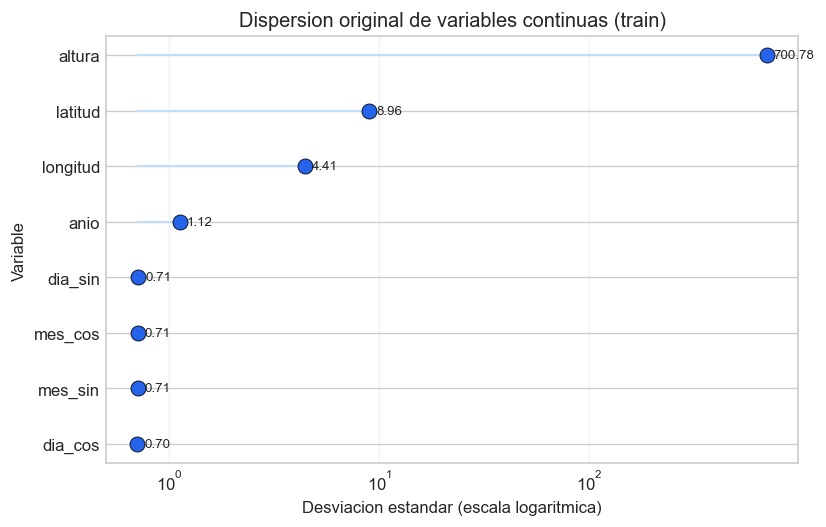

In [74]:
resumen_std = resumen_pre_escalado["std"].sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
y_pos = np.arange(len(resumen_std))

ax.scatter(
    resumen_std.values,
    y_pos,
    s=80,
    color="#2563eb",
    edgecolors="#0f172a",
    linewidth=0.6,
    zorder=3,
)

for x, y in zip(resumen_std.values, y_pos):
    ax.hlines(y, xmin=resumen_std.min(), xmax=x, color="#bfdbfe", linewidth=1.2, zorder=1)
    ax.text(x * 1.08, y, f"{x:.2f}", va="center", fontsize=8)

ax.set_xscale("log")
ax.set_title("Dispersion original de variables continuas (train)")
ax.set_xlabel("Desviacion estandar (escala logaritmica)")
ax.set_ylabel("Variable")
ax.set_yticks(y_pos)
ax.set_yticklabels(resumen_std.index)
ax.grid(axis="x", alpha=0.25, zorder=0)
plt.tight_layout()
plt.show()


**Analisis.** El grafico confirma que las variables continuas operan en escalas muy distintas incluso dentro del bloque de ajuste. `altura` domina claramente la dispersion, mientras que las componentes ciclicas trabajan en rangos mucho mas acotados. Si no se corrige esta diferencia, un algoritmo sensible a magnitudes tendera a privilegiar variables solo por su escala numerica y no necesariamente por su aporte real.


In [75]:
escalador = StandardScaler()
columnas_escaladas = [f"{col}_z" for col in columnas_continuas]

valores_train_escalados = escalador.fit_transform(df_train_ref[columnas_continuas])
valores_test_escalados = escalador.transform(df_test_ref[columnas_continuas])

columnas_base = [
    "fecha", "codigo_estacion", "nombre_estacion", "nombre_region",
    "zona_geografica", "macrozona", "zona_climatica", "agua_caida", "agua_caida_imputada"
]

df_train_escalado = df_train_ref[columnas_base].copy()
df_test_escalado = df_test_ref[columnas_base].copy()

df_train_escalado[columnas_escaladas] = valores_train_escalados
df_test_escalado[columnas_escaladas] = valores_test_escalados

df_train_escalado["bloque_temporal"] = "train"
df_test_escalado["bloque_temporal"] = "test"
df_escalado = pd.concat([df_train_escalado, df_test_escalado], axis=0).sort_values("fecha").reset_index(drop=True)

resumen_post_escalado = df_train_escalado[columnas_escaladas].agg(["mean", "std", "min", "max"]).T.round(3)
display(resumen_post_escalado)


,mean,std,min,max
altura_z,0.0,1.0,-0.586,5.235
latitud_z,0.0,1.0,-2.940,2.037
longitud_z,0.0,1.0,-8.566,2.889
anio_z,0.0,1.0,-1.389,1.284
mes_sin_z,0.0,1.0,-1.398,1.434
mes_cos_z,0.0,1.0,-1.408,1.418
dia_sin_z,-0.0,1.0,-1.399,1.419
dia_cos_z,0.0,1.0,-1.415,1.425


**Aplicacion del escalador.** Con `StandardScaler`, el ajuste se realiza solo con el bloque `train` y luego se aplica a `test` sin recalcular parametros. Esta decision evita una transformacion contaminada por informacion futura y deja la fase 3 alineada con un flujo de modelamiento mas realista.


In [76]:
comparacion_escalamiento = pd.DataFrame(
    {
        "media_original_train": resumen_pre_escalado["mean"],
        "std_original_train": resumen_pre_escalado["std"],
        "media_escalada_train": resumen_post_escalado["mean"].values,
        "std_escalada_train": resumen_post_escalado["std"].values,
    },
    index=columnas_continuas,
).round(3)

display(comparacion_escalamiento)


,media_original_train,std_original_train,media_escalada_train,std_escalada_train
altura,415.703,700.778,0.0,1.0
latitud,-35.846,8.962,0.0,1.0
longitud,-71.703,4.405,0.0,1.0
anio,2022.559,1.122,0.0,1.0
mes_sin,-0.013,0.706,0.0,1.0
mes_cos,-0.004,0.708,0.0,1.0
dia_sin,-0.007,0.710,-0.0,1.0
dia_cos,-0.003,0.704,0.0,1.0


La tabla compara de forma directa el estado de las variables continuas antes y despues del `StandardScaler`. El grafico siguiente condensa esa comparacion para que la homogenizacion de escala se vea de manera inmediata.


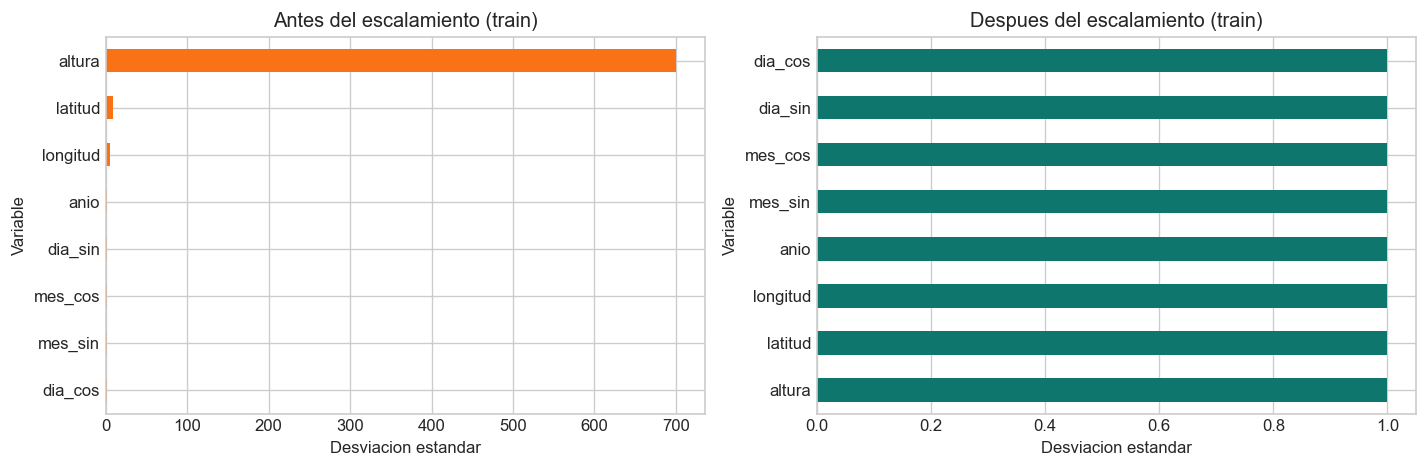

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparacion_escalamiento["std_original_train"].sort_values().plot(kind="barh", ax=axes[0], color="#f97316")
axes[0].set_title("Antes del escalamiento (train)")
axes[0].set_xlabel("Desviacion estandar")
axes[0].set_ylabel("Variable")

comparacion_escalamiento["std_escalada_train"].sort_values().plot(kind="barh", ax=axes[1], color="#0f766e")
axes[1].set_title("Despues del escalamiento (train)")
axes[1].set_xlabel("Desviacion estandar")
axes[1].set_ylabel("Variable")

plt.tight_layout()
plt.show()


**Analisis.** La comparacion antes y despues del escalamiento muestra que la transformacion no modifica la existencia de patrones, pero si vuelve comparable la contribucion potencial de cada predictor. En el bloque de ajuste, las medias quedan cercanas a cero y las desviaciones estandar se aproximan a uno, lo que confirma que la estandarizacion se aplico correctamente sin mezclar informacion del bloque temporal posterior.


In [78]:
dummies_train = pd.get_dummies(
    df_train_escalado[["macrozona", "zona_climatica"]],
    prefix=["macrozona", "clima"],
    dtype=int,
    drop_first=True,
)
dummies_test = pd.get_dummies(
    df_test_escalado[["macrozona", "zona_climatica"]],
    prefix=["macrozona", "clima"],
    dtype=int,
    drop_first=True,
).reindex(columns=dummies_train.columns, fill_value=0)

X_train_preparado = pd.concat([df_train_escalado[columnas_escaladas], dummies_train], axis=1)
X_test_preparado = pd.concat([df_test_escalado[columnas_escaladas], dummies_test], axis=1)
y_train_objetivo = df_train_escalado["agua_caida"].copy()
y_test_objetivo = df_test_escalado["agua_caida"].copy()

resumen_modelado = pd.DataFrame(
    {
        "bloque": ["train", "test"],
        "filas_X": [len(X_train_preparado), len(X_test_preparado)],
        "filas_y": [len(y_train_objetivo), len(y_test_objetivo)],
        "targets_imputados_en_bloque": [
            int(df_train_escalado["agua_caida_imputada"].sum()),
            int(df_test_escalado["agua_caida_imputada"].sum()),
        ],
        "columnas_X": [X_train_preparado.shape[1], X_test_preparado.shape[1]],
    }
)

display(resumen_modelado)
display(X_train_preparado.head())


,bloque,filas_X,filas_y,targets_imputados_en_bloque,columnas_X
0,train,133448,133448,0,21
1,test,37365,37365,0,21


,altura_z,latitud_z,longitud_z,anio_z,mes_sin_z,mes_cos_z,dia_sin_z,dia_cos_z,macrozona_Centro,macrozona_Norte,macrozona_Sur,clima_Des?rtico y Estep?rico de altura,clima_Estep?rico costero,clima_Estep?rico interior,clima_Estepario fr?o,clima_Mar?timo lluvioso,clima_Mediterr?neo seco,clima_Mediterr?neo seco y h?medo,clima_Templado y lluvioso,clima_Tropical lluvioso,clima_Tundra
156266,-0.093757,-0.819403,-0.033838,-1.388737,0.725989,1.22847,0.03411,1.424645,0,0,1,0,0,0,0,0,0,0,1,0,0
176929,-0.342054,-1.850473,0.065173,-1.388737,0.725989,1.22847,0.03411,1.424645,0,0,0,0,0,0,1,0,0,0,0,0,0
109182,-0.376302,-0.082582,-0.075714,-1.388737,0.725989,1.22847,0.03411,1.424645,0,0,1,0,0,0,0,0,0,1,0,0,0
1096,-0.520428,1.951693,0.309421,-1.388737,0.725989,1.22847,0.03411,1.424645,0,1,0,0,0,0,0,0,0,0,0,0,0
126325,-0.102319,-0.314127,-0.204868,-1.388737,0.725989,1.22847,0.03411,1.424645,0,0,1,0,0,0,0,0,0,0,1,0,0


**Construccion del set final.** La fase 3 deja una base considerablemente mas robusta que la version inicial. `y_train_objetivo` y `y_test_objetivo` se construyen solo con precipitaciones observadas, el escalamiento se ajusta sin fuga de informacion y las dummies territoriales ya incorporan tanto `macrozona` como `zona_climatica`. En consecuencia, la salida de esta fase no solo preserva la logica temporal del train/test, sino que tambien deja representadas las clasificaciones territoriales que mostraron valor analitico durante la fase 2.
